## Utilizing news sentiment to predict future price of the Vanguard ETF



Modeling and predicting future prices has long been a challenging problem that researchers and traders alike have attempted to address. The prevailing Efficient Market Hypothesis states that all information in the capital markets is fully reflected at all times, such that prices never deviate from their fair market value (Downey, 2025). An efficient market is one in which the price reflects all information of an underlying security. (Fama, 1970) Proponents of the EFH state that, in the long run, active investment strategies will fail to perform better than passive investment strategies. While it may be true that a grand majority of active market participants fail to perform better than passive investment strategies (e.g., buy and hold the S&P 500), this is not universally true.

There are countless examples of individuals successfully outperforming the market, all employing some sort of active trading strategy. For instance, Warren Buffett garnered vast amounts of wealth by detecting and purchasing undervalued stock. This can be viewed as a fundamental active trading style. Other notable examples are the Turtle Traders and Richard Wychoff, the latter employing a rules-based strategy and the former employing rigorous technical analysis for market entry and exits. These investors serve as precedents and counterarguments that the market is not perfectly efficient. The success of these traders suggests that information can be acquired to gain an edge in the markets and become a successful active market participant. To this point, in recent years, state-of-the-art models have been attempting to utilize the flexibility in machine learning algorithms to gain an edge and predict future prices or directional predictions.

The advent of neural networks has enabled the analysis of a large corpus of textual financial news headlines, an insurmountable task once infeasible. More specifically, extracting aggregated daily sentiment from new headlines is now possible using transformer-based neural network architectures. Utiliing these novel techiques, this project intents to expore how textual analysis alongside univariate price can be used in the financial markets for resource allocation and risk management. As such, this project intends to evaluate two objectives:
- Does incorporating aggregated daily sentiment alongside univariate price improve predictive performance?

- Does incorporating news sentiment alongside price in network modeling improve predictive performance over traditional ARIMA modeling?

The result from this project will provide insight on whether it is possible to utilize sentiment analysis to improve model performance. Additionally, it will provide insight on whether it it possible to outperform traditional statistical predictive modeling using daily news headline sentiment.

## References
Downey, L. (2025, November 15). Efficient Market Hypothesis (EMH): Definition and Critique. Retrieved from Investopedia: https://www.investopedia.com/terms/e/efficientmarkethypothesis.asp

Fama, E. F. (1970). Efficient Capital Markets: A Review of Theory and Empirical Work. Wiley for the American Finance Association, Haas School of Business.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import keras
import tensorflow
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading in data
loc_van = r'/content/drive/MyDrive/Spring 2026/Deep Learning Project 2/VGT ETF Stock Price History.csv'
loc_sentiment = r'/content/drive/MyDrive/Spring 2026/Deep Learning Project 2/Sentiment.csv'
loc_news = r'/content/drive/MyDrive/Spring 2026/Deep Learning Project 2/Vangard_top_25_tickers_news_articles.csv'

In [ ]:
# Reading in the three data types
df_sentiment = pd.read_csv(loc_sentiment)
df_van = pd.read_csv(loc_van)
df_news = pd.read_csv(loc_news)

Reviewing the number of rows

In [ ]:
# Creting keys for each dataframe
datas = {'news': df_news, 'sentiment_df':df_sentiment, 'vanguard':df_van}

for key, dataset in datas.items():
  print(f'The number of rows in the {key} dataset is {dataset.shape[0]}')

The number of rows in the news dataset is 99640
The number of rows in the sentiment_df dataset is 5842
The number of rows in the vanguard dataset is 2559


# Data Profiling

# Profiling the Vanguard ETF dataset

In [ ]:
# Reviewing data structure
df_van.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2559 entries, 0 to 2558
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      2559 non-null   object 
 1   Price     2559 non-null   float64
 2   Open      2559 non-null   float64
 3   High      2559 non-null   float64
 4   Low       2559 non-null   float64
 5   Vol.      2554 non-null   object 
 6   Change %  2559 non-null   object 
dtypes: float64(4), object(3)
memory usage: 140.1+ KB


In [ ]:
# Reviewing descriptive stats
df_van.describe()

,Price,Open,High,Low
count,2559.000000,2559.000000,2559.000000,2559.000000
mean,338.271286,338.250883,340.854345,335.299273
std,181.675057,181.807739,183.094533,180.073258
min,94.190000,93.400000,94.920000,92.950000
25%,181.255000,181.105000,182.825000,179.665000
50%,327.790000,327.260000,331.260000,324.400000
75%,441.130000,440.000000,444.815000,437.165000
max,801.520000,803.360000,806.990000,795.970000


In [ ]:
# Viewing first few rows
df_van.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,02/27/2026,726.70,726.68,732.53,723.38,529.67K,-1.82%
1,02/26/2026,740.19,751.99,751.99,732.45,395.09K,-1.47%
2,02/25/2026,751.26,742.70,753.32,742.00,492.42K,1.89%
3,02/24/2026,737.30,729.41,740.42,726.10,349.62K,1.44%
4,02/23/2026,726.85,735.16,737.08,723.84,446.21K,-1.46%


In [ ]:
# Checking missing data
df_van.isna().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,5
Change %,0


Plotting the dataframe

In [ ]:
# Setting the date column as a pd.datetime object
df_van['Date'] = pd.to_datetime(df_van['Date'])

# Crrating a copy
df_van_plot = df_van.copy()

# Setting date as the index for plotting
df_van_plot = df_van_plot.set_index('Date')

Text(0.5, 1.0, 'Closing Price of Vanguard ETF for the Period: 01/01/2016 - 02/28/26')

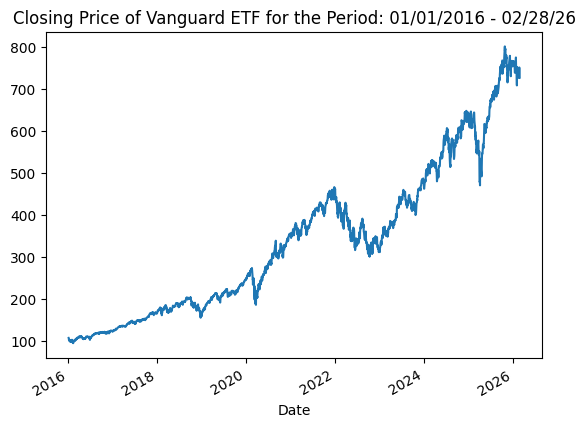

In [ ]:
# Creating a visualization of price for the last five years
df_van_plot['Price'].plot()

# Adding title
plt.title('Closing Price of Vanguard ETF for the Period: 01/01/2016 - 02/28/26')

In [ ]:
# Adding moving averages
df_van['200-day SMA'] = df_van['Price'][::-1].rolling(window=200).mean()
df_van['50-day SMA'] = df_van['Price'][::-1].rolling(window=50).mean()

## Creating a candle stick chart

In [ ]:

# Candle colors
open_close_color = (
    alt.condition("datum.Open <= datum['Price']", alt.value("#06982d"), alt.value("#ae1325") ))

# Creating baseline chart
base = alt.Chart(df_van, title='The Vanguard ETF has steadly increased in price over time').encode(
    alt.X('Date:T')
        .axis(format='%m/%d%y', labelAngle=-45)
        .title('Date'),
    color=open_close_color
)

# Creating moving averages
moving_average_200SMA = alt.Chart(df_van).mark_line(color='blue').encode(
    alt.X('Date:T', title='Date'),
    alt.Y('200-day SMA:Q'),
).properties(width=500, height=500)

moving_average_50SMA = alt.Chart(df_van).mark_line(color='red').encode(
    alt.X('Date:T', title='Date'),
    alt.Y('50-day SMA:Q'),
).properties(width=500, height=500)

# Plotting bar marks
rule = base.mark_rule().encode(
    alt.Y('Low:Q')
        .title('Price')
        .scale(zero=False),
    alt.Y2('High:Q'))

bar = base.mark_bar().encode(
    alt.Y('Open:Q'),
    alt.Y2('Price:Q')
)

# Combining charts
candle_chart = rule + bar + moving_average_200SMA + moving_average_50SMA

candle_chart.properties(width=1000, height=400).interactive()

alt.LayerChart(...)

Plot is interactive

# Profiling the sentiment dataset

In [ ]:
# Viewing data structure
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [ ]:
# Reviewing the data
df_sentiment.head(10)

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
5,$SPY wouldn't be surprised to see a green close,positive
6,Shell's $70 Billion BG Deal Meets Shareholder ...,negative
7,SSH COMMUNICATIONS SECURITY CORP STOCK EXCHANG...,negative
8,Kone 's net sales rose by some 14 % year-on-ye...,positive
9,The Stockmann department store will have a tot...,neutral


In [ ]:
# Reviewing proportions
print(df_sentiment.Sentiment.value_counts(normalize=True))
print(df_sentiment.Sentiment.value_counts())

Sentiment
neutral     0.535775
positive    0.317015
negative    0.147210
Name: proportion, dtype: float64
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64


Proportionately there is imbalance between the classes. We might be able to innovatively augment sentences using either a rules-based approach to substitute name entities to generate new negative and positive statements. Alternatively, we could use a LLM for this, although it will be more difficult to ensure its quality.

Creating a visualization of sentiment classes

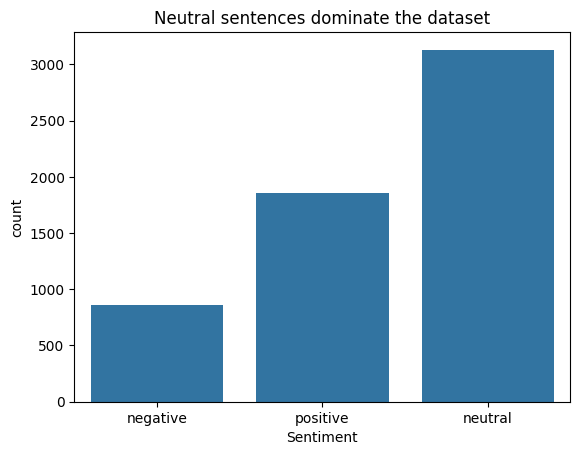

In [ ]:
# Specifying order of plot
order = ['negative', 'positive','neutral']

# Creating plot
sns.countplot(data=df_sentiment, x='Sentiment', order=order)
plt.title('Neutral sentences dominate the dataset')
plt.show()

## Using topic modeling to evalutate if the topics formulated match its classification.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Creating masks for analysis
mask_positive = df_sentiment['Sentiment'] == 'positive'
mask_negative = df_sentiment['Sentiment'] == 'negative'
mask_neutral = df_sentiment['Sentiment'] == 'neutral'

# TF-IDF
tfidf = TfidfVectorizer(max_features=400)
X_tfidf_positive = tfidf.fit_transform(df_sentiment[mask_positive]['Sentence'])
X_tfidf_negative = tfidf.fit_transform(df_sentiment[mask_negative]['Sentence'])
X_tfidf_neutral = tfidf.fit_transform(df_sentiment[mask_neutral]['Sentence'])

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# LDA - Positive sentiment
lda = LatentDirichletAllocation(n_components=8, random_state=42)
lda.fit(X_tfidf_positive)

# Display top words per topic
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}", [tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

Topic 0 ['total', 'building', 'general', 'now', 'operating', 'who', 'in', 'around', 'is', 'they']
Topic 1 ['paper', 'available', 'brand', 'line', 'while', 'is', 'total', 'operating', 'around', 'they']
Topic 2 ['increase', 'unit', 'be', 'other', 'agreement', 'manufacturing', 'internet', 'stock', 'international', 'currently']
Topic 3 ['solutions', 'sell', 'related', 'units', 'full', 'major', 'president', 'since', 'term', 'construction']
Topic 4 ['total', 'general', 'whole', 'around', 'totaled', 'for', 'sanoma', 'per', 'plc', 'local']
Topic 5 ['other', 'most', 'russian', 'shares', 'processing', 'can', 'co', 'general', 'total', 'petersburg']
Topic 6 ['based', 'around', 'network', 'general', 'employs', 'had', 'an', 'down', 'unit', 'basware']
Topic 7 ['second', 'nordea', 'projects', 'total', 'operating', 'is', 'growth', 'they', 'negotiations', 'euros']


In [ ]:
# LDA - Negative sentiment
lda = LatentDirichletAllocation(n_components=8, random_state=77)
lda.fit(X_tfidf_negative)

# Display top words per topic
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}", [tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

Topic 0 ['maker', 'operations', 'trade', 'issued', 'billion', 'co', 'available', 'by', 'including', 'third']
Topic 1 ['available', 'totaled', 'line', 'largest', 'to', 'third', 'service', 'start', 'investment', 'corporation']
Topic 2 ['totaled', 'co', 'their', 'he', 'our', 'network', 'corporation', 'mr', 'under', 'is']
Topic 3 ['now', 'before', 'currently', 'totaled', 'growth', 'russian', 'available', 'issued', 'operations', 'third']
Topic 4 ['following', 'totaled', 'helsinki', 'details', 'construction', 'revenue', 'used', 'be', 'security', 'price']
Topic 5 ['equipment', 'internet', 'third', 'expects', 'europe', 'personnel', 'operations', 'totaled', 'fell', 'negotiations']
Topic 6 ['earnings', 'third', 'operations', 'totaled', 'production', 'own', 'have', 'issued', 'expected', 'net']
Topic 7 ['issue', 'food', 'plant', 'earlier', 'our', 'second', 'area', 'use', 'order', 'amounted']


In [ ]:
# LDA neutral
lda = LatentDirichletAllocation(n_components=8, random_state=25)
lda.fit(X_tfidf_neutral)

# Display top words per topic
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}", [tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

Topic 0 ['will', 'this', 'media', 'is', 'of', 'and', 'in', 'on', 'market', 'the']
Topic 1 ['and', 'to', 'total', 'be', 'in', 'shares', 'value', 'is', 'of', 'the']
Topic 2 ['services', 'for', 'is', 'will', 'as', 'to', 'of', 'in', 'and', 'the']
Topic 3 ['as', 'can', 'be', 'is', 'industry', 'of', 'no', 'in', 'and', 'the']
Topic 4 ['will', 'all', 'have', 'has', 'in', 'is', 'of', 'and', 'to', 'the']
Topic 5 ['general', 'long', 'capital', 'is', 'by', 'ceo', 'to', 'of', 'the', 'not']
Topic 6 ['and', 'board', 'in', 'company', 'to', 'approximately', 'as', 'per', 'of', 'the']
Topic 7 ['from', 'million', 'the', 'of', 'sales', 'net', 'in', 'profit', 'mn', 'eur']


Overall, the topics formed from LDA topic modeling correspond to its topic, ensuring data quality. Reviewing the positive topics, we see that topics like “Topic 7” include terms (e.g., “negotiation”, “projects”, “operating”) describing diplomatic negotiations in a positive light. Connecting this in recent times, the markets often reacted positively to headlines of negotiations, especially after the Liberation Day tariffs were implemented. Negotiation often involves putting in place policies that benefit both parties involved and are often received with positive sentiment.

The topics generated by the LDA model for the negative sentiment observations seem to be in line with the overall negative sentiment construct. Topics 0,3,5 appear to be representing current business operational issues and their substantial cost given by the keywords “issue”, “billion”, “operations”, “fell”, and others. Topics 4-7 appear to be topics such as reduced earnings due to production issues (topic 6) and supply chain issues (topic 7). Overall, the topics do appear to be constructing subtopics of negative business sentiment.

The last LDA topic modeling on neutral sentiment produces more neutral groups, but, at times, vague compared to the positive and negative sentiment topics. A common theme across many topics is the upcoming release of information.  The keyword “will” is utilized in many topics (e.g., Topic 0,2, and 4) to communicate the upcoming release of financial reporting. Such topics as intuitively neutral as market participants have no objective information to change their investment strategies other than to wait for the upcoming release of information.

Overall, the LDA modeling of these various sentiment constructs in the data appears to be appropriate for sentiment analysis. It is anticipated that by fitting a model on this dataset to predict sentiment in news titles, it will be possible to detect sentiment in the new articles of the top 25 stocks in the Vanguard Technology ETF. Using the predictions, aggregated daily sentiment will be computed to concatenate the results with the Vanguard ETF dataset, effectively creating a multivariate timeseries dataset for modeling.



# Profiling the news data

In [ ]:
# Catching data
df_news_catche = df_news.copy()

In [ ]:
# Reviewing the overall structure of the data
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99640 entries, 0 to 99639
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     99640 non-null  int64 
 1   Date           99640 non-null  object
 2   Article_title  99640 non-null  object
 3   Stock_symbol   99640 non-null  object
 4   Url            99640 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
# Converting the date to a datetime object
df_news['Date'] = pd.to_datetime(df_news['Date'])

In [ ]:
# Reviewing the date range of the data
print(f"The data contains news information from {df_news['Date'].min()} - {df_news['Date'].max()}")


The data contains news information from 2009-08-17 00:00:00+00:00 - 2023-12-16 23:02:00+00:00


In [ ]:
# Creating a groupby dataframe
data = df_news.groupby('Date')['Article_title'].count()

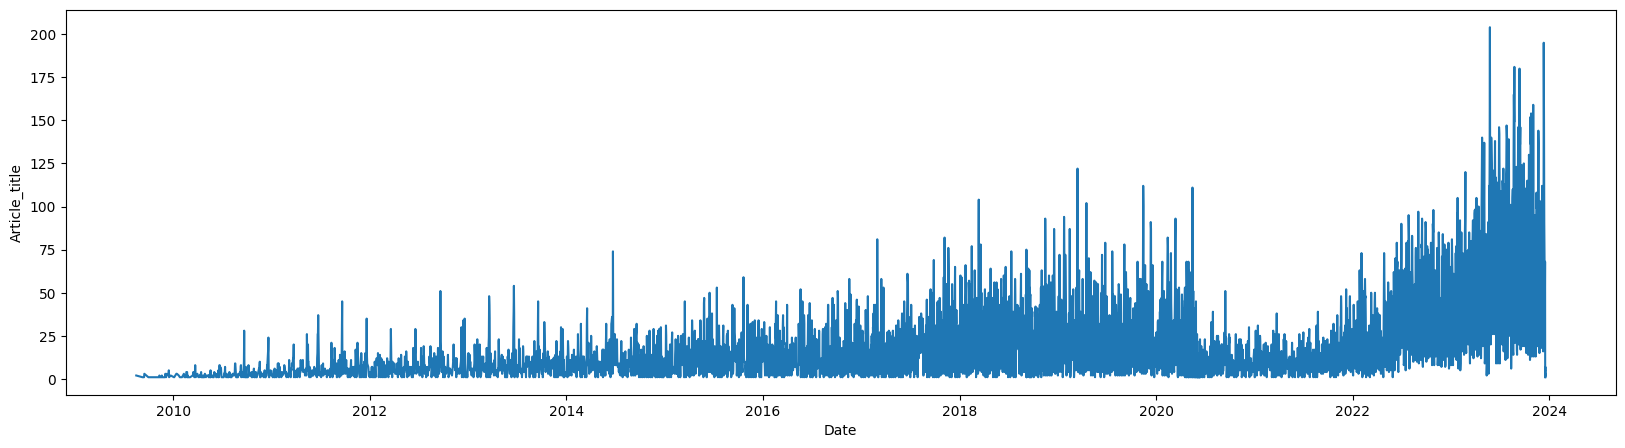

In [ ]:
# Creating a plot
plt.figure(figsize=(20,5))
sns.lineplot(data=data.reset_index(), x='Date', y='Article_title')
plt.show()

In [ ]:
# Filtering the dataframe
filtered_df = df_news[(df_news['Date'] >= '2022-01-01')
                     & (df_news['Date'] < '2022-12-31')]

In [ ]:
# Creating groupby
data = filtered_df.groupby('Date')['Article_title'].count()

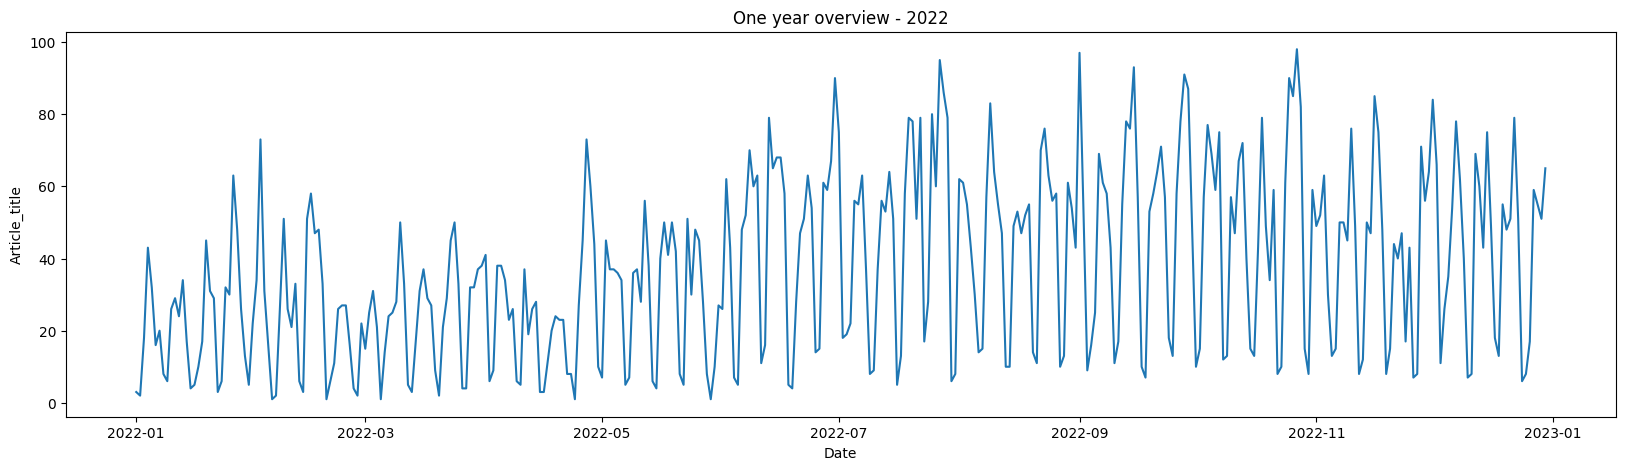

In [ ]:
# Creating a plot
plt.figure(figsize=(20,5))
sns.lineplot(data=data.reset_index(), x='Date', y='Article_title')
plt.title('One year overview - 2022')
plt.show()

In [ ]:
# Filtering the dataframe
filtered_df = df_news[(df_news['Date'] >= '2022-03-06')
                     & (df_news['Date'] < '2022-3-27')]

In [ ]:
# Creating groupby
data = filtered_df.groupby('Date')['Article_title'].count()

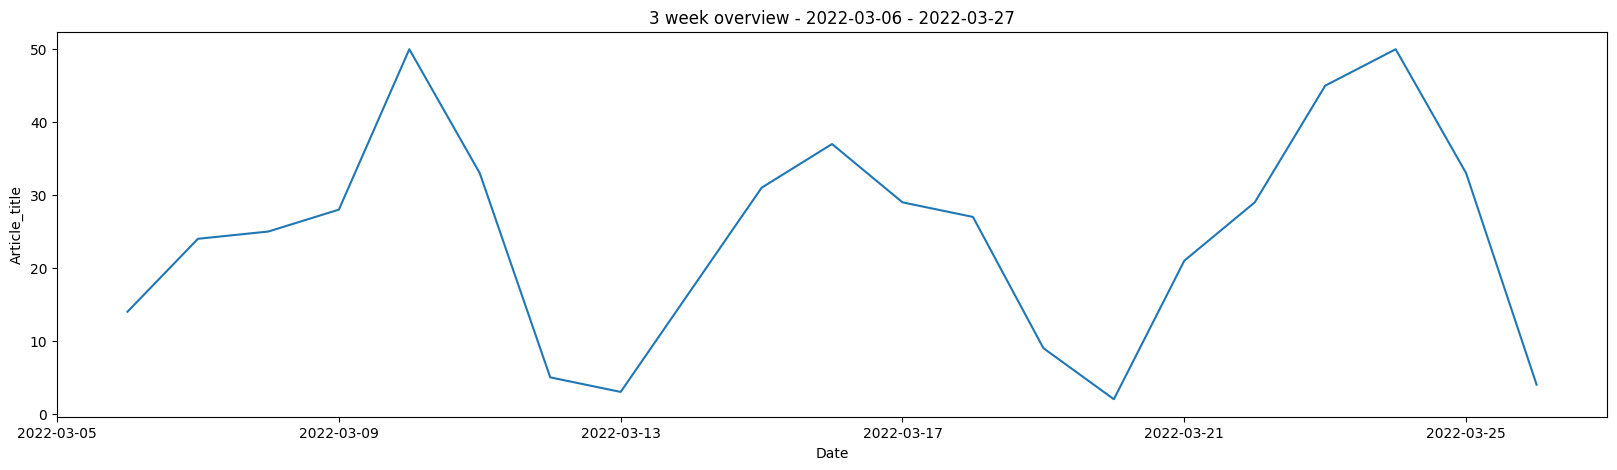

In [ ]:
# Creating a plot
plt.figure(figsize=(20,5))
sns.lineplot(data=data.reset_index(), x='Date', y='Article_title')
plt.title('3 week overview - 2022-03-06 - 2022-03-27')
plt.show()

Viewing the visualizations, we find that the new data is a comprehensive dataset. The total overview of the dataset reviews that there are news articles ranging from late 2009 to late 2023. The frequency of the daily new articles grows as time goes on, until mid-2020, when presumably news about Covid 19 was predominant at the time. Starting in 2022, there was a buildup of daily news articles, reaching its peak at around 200 news articles in one day. Moving to a more granular view, the second chart focuses on a one-year overview. In this visualization, it is apparent that there is a cyclical nature in the number of news articles released per day. This cyclical nature is likely due to the release of publications during the weekdays. Assuming this is the case, the dataset is very dense, which is desired for incorporating news sentiment into daily market predictions. Lastly, the final visualization confirms our intuition about the weekends and the number of publications. Throughout the weekdays we have meaningful amounts of news publications, with troughs on Sundays and peaks around mid-week (i.e., Wednesday/Thursday).  

Initial data profiling revealed valuable information regarding the data quality and its comprehension. The initial data profiling of the Vanguard ETF market prices did not reveal any extraneous values or information. A visualization of the totality of the dataset revealed the overall bullish trend of the ETF, with technical indicators added for trend confirmation. Profiling the sentiment dataset revealed a potential imbalancing issue for modeling. It was revealed that neutral sentences dominated the dataset, followed by positive and negative sentiment. Diving deeper into the quality of the dataset, LDA was performed, where groups were created for each sentiment construct. Within each group, it was found that the subtopics of the overall construct were related, thus ensuring that the sentiment model would learn appropriate patterns from the dataset. Lastly, interrogation of the news dataset illustrated its comprehensiveness. Data is available from late 2009 to late 2023, which will be more than sufficient for this analysis. Overall, the dataset seems to be of sound quality, and a substantial amount of data cleaning will not be necessary to perform modeling. A literature review will still prove beneficial to understand if any data preprocessing steps are beneficial for modeling.

# Creating a baseline model

In [ ]:
# Importing necessary packages
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [ ]:
# Filtering the dataframe
df = df_van[(df_van['Date'] >= df_van['Date'].min())
                     & (df_van['Date'] < '2023-12-01')]

In [ ]:
# Reversing order
df = df.iloc[:,:2][::-1].reset_index(drop=True)

In [ ]:
# Reviewing transformation
df.head()

,Date,Price
0,2016-01-04,106.61
1,2016-01-05,106.10
2,2016-01-06,104.66
3,2016-01-07,101.29
4,2016-01-08,100.42


In [ ]:
# Reviewing min date
df['Date'].min()

Timestamp('2016-01-04 00:00:00')

In [ ]:
# Reviewing max date for sanity check
df['Date'].max()

Timestamp('2023-11-30 00:00:00')

In [ ]:
# Converting price to percent change
df['Percent_change'] = df['Price'].pct_change()

# Dropping first row
df.dropna(inplace=True)

In [ ]:
# Split data for time series models
ts_split_idx = int(len(df)*0.70)
train_prices = df.iloc[:ts_split_idx]
test_prices = df.iloc[ts_split_idx:]

In [ ]:
# Calculating the auto correlation function (ACF)
acf_values, confidence = acf(train_prices['Price'], nlags=50, alpha=0.05)

# Extracting confidence intervals
upper_bound = []
lower_bound = []
for x in confidence:
    lower = x[0]
    upper = x[1]

    lower_bound.append(lower)
    upper_bound.append(upper)

# Creating a dictionary
acf_values = {'acf_values': acf_values, 'lower_bound': lower_bound, 'upper_bound':upper_bound}

df_acf_values = pd.DataFrame(acf_values)

df_acf_values.head()

,acf_values,lower_bound,upper_bound
0,1.000000,1.000000,1.000000
1,0.996581,0.944143,1.049020
2,0.993372,0.902753,1.083991
3,0.989893,0.873108,1.106678
4,0.986297,0.848356,1.124238


## Checking assumptions

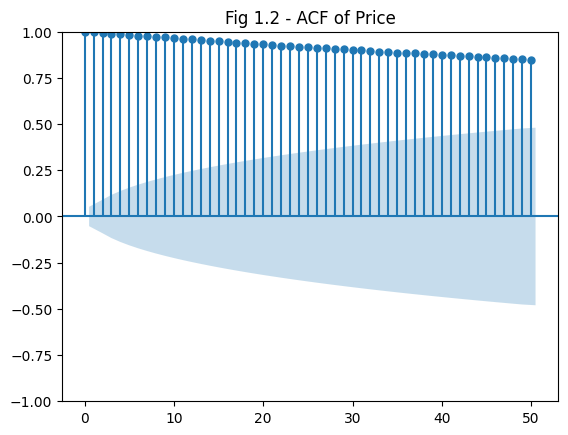

In [ ]:
# Plotting 'log(ipi)' ACF values
plot_acf(train_prices['Price'], lags=50)

# Creating title for plot
plt.title('Fig 1.2 - ACF of Price')

# Plotting
plt.show()

In [ ]:
# Plotting differenced values
alt.Chart(train_prices, title='Percent Change').mark_line().encode(
    x = alt.X('Date:T'),
    y = alt.Y('Percent_change:Q', scale=alt.Scale(domain=[train_prices['Percent_change'].min(), train_prices['Percent_change'].max()]))
).properties(width=400, height=400)

alt.Chart(...)

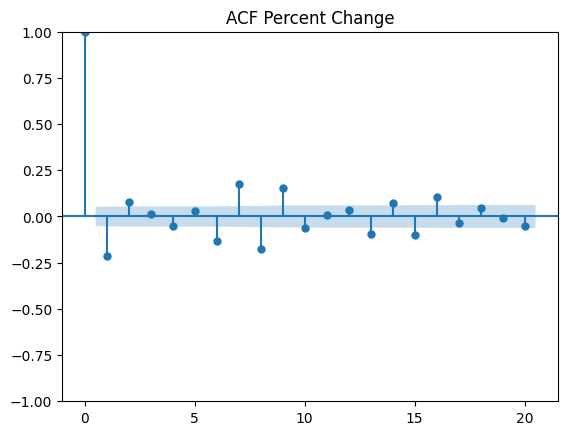

In [ ]:
# ACF of differenced log
plot_acf(train_prices['Percent_change'], lags=20)
plt.title('ACF Percent Change')
plt.show()

In [ ]:
# ADF test (Phillips-Perron equivalent)
adf_result = adf_result = adfuller(train_prices['Percent_change'])
print(f'ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}')

ADF Statistic: -12.416055907283372, p-value: 4.238188461249972e-23


The null hypothesis of the Augmented Dickey-Fuller test is that the series has a unit root (or is non-stationary). The alternative hypthesis is that the series is stationary. Given a ADF test statistic of -12.41 ($p<0.05$), we reject the null hypothesis that the series is non-stationary. Thus, no additional preprocessing (e.g., differencing) is needed to prepare the data from ARIMA modeling.

## Hyperparameter tuning

In [ ]:
# Grid search for ARMA(p,q)
import warnings
warnings.filterwarnings('ignore')
pmax, qmax = 7, 7

# Creating y variable
y = train_prices['Percent_change']

# Initializing matrix
aic_matrix = np.full((pmax + 1, qmax + 1), np.nan)
bic_matrix = np.full((pmax + 1, qmax + 1), np.nan)

for p in range(pmax + 1):
    for q in range(qmax + 1):
        try:
            model = ARIMA(y, order=(p, 0, q)).fit()
            aic_matrix[p, q] = model.aic
            bic_matrix[p, q] = model.bic
        except:
            continue

print("AIC Matrix:\n", aic_matrix)
print("BIC Matrix:\n", bic_matrix)

AIC Matrix:
 [[-7808.49779979 -7863.37676151 -7871.78824476 -7869.96890645
  -7871.91121152 -7869.83551757 -7879.12387469 -7894.65082678]
 [-7870.29173048 -7869.46255801 -7868.63502743 -7867.99139469
  -7877.44844365 -7895.11798256 -7901.39161726 -7906.2744751 ]
 [-7870.02630798 -7868.38693571 -7868.34173857 -7865.82995354
  -7865.66567727 -7897.89888256 -7938.22891221 -7933.90269094]
 [-7870.33972289 -7867.79988488 -7867.08886531 -7863.83957913
  -7884.79073948 -7916.29939527 -7941.60795189 -7934.10095326]
 [-7871.30346848 -7869.31626649 -7866.91936695 -7890.33648941
  -7849.40803323 -7930.07495638 -7940.67990403 -7939.00095708]
 [-7869.36052921 -7867.25152681 -7864.91766919 -7863.55454684
  -7840.13567706 -7928.34297027 -7938.59205313 -7935.13201065]
 [-7889.7935178  -7929.53125303 -7880.14550496 -7892.14772648
  -7864.35183097 -7941.93696334 -7941.39086048 -7940.68588103]
 [-7913.53260629 -7907.90284021 -7933.95680013 -7915.12881107
  -7894.69870593 -7939.79419391 -7931.62331788 -79

In [ ]:
# Extracting best parameters from grid search
best_aic = np.unravel_index(np.nanargmin(aic_matrix), aic_matrix.shape)
best_bic = np.unravel_index(np.nanargmin(bic_matrix), bic_matrix.shape)

# Printing best parameters
print("Best AIC model (p,q):", best_aic)
print("Best BIC model (p,q):", best_bic)

Best AIC model (p,q): (np.int64(6), np.int64(5))
Best BIC model (p,q): (np.int64(2), np.int64(6))


## Obtaining one step predictions

In [ ]:
# Creating empty list to store results
predictions = []
history = train_prices['Percent_change'].tolist()

for i in range(len(test_prices['Percent_change'])):
    # Fitting best model
    model = ARIMA(history, order=(best_bic[0], 0, best_bic[1]))
    model_fit = model.fit()

    # Predict the next step
    yhat = model_fit.forecast()[0]

    # Appending one-step predictions
    predictions.append(yhat)

    # Add actual observation to history for the next prediction
    obs = test_prices['Percent_change'].iloc[i]
    history.append(obs)

In [ ]:
# Reviewing predictions
predictions[0:10]

[np.float64(0.004498629191269674),
 np.float64(-0.003413724287804453),
 np.float64(0.0002517121072681131),
 np.float64(0.0026016500425268332),
 np.float64(-0.0003118325384240616),
 np.float64(0.002388308709755228),
 np.float64(4.47803629155622e-05),
 np.float64(0.0021933661179542614),
 np.float64(-0.0014603432876187992),
 np.float64(0.00204936169900852)]

## Creating a process to converted percent changes back to original units

In [ ]:
# Obtaining the last price prior to test dataset
last_train_price = train_prices.iloc[-1]['Price']

# Empty list to store converted percent changes back to predicted prices
predicted_prices_list = []

# Setting the last train price as the previous step price for predicted price computation
current_price_base = last_train_price

# Setting index that will be used to extract the previous step daily price
i=0
for pct_change in predictions:
    if i==0: # This loop uses the last train price as the previous period price

      # Obtaining the predicted price
      predicted_current_price = current_price_base * (1 + pct_change)

      # Appending the predicted price to the list
      predicted_prices_list.append(predicted_current_price)

      # Setting the "current_price_base" to the current steps index
      current_price_base = test_prices.iloc[i]['Price']

      # Adding one to the index indicator
      i+=1
    else:
      try: # this loop begins using the "test_prices" as the previous step

        # Obtaining the predicted price
        predicted_current_price = current_price_base * (1 + pct_change)

        # Appending the predicted price to the predicted price list
        predicted_prices_list.append(predicted_current_price)

        # Updating the "current_price_base" to the most recent index "i"
        current_price_base = test_prices.iloc[i]['Price']

        # Adding one to the index indicator
        i+=1
      except:
        break

# Creating a dataframe of the predicted values
predicted_prices_df = pd.DataFrame({
    'Predicted_Price': predicted_prices_list
})

# Align the actual test prices with the predicted prices
actual_prices_for_comparison = test_prices.reset_index(drop=True)
predicted_prices_df['Actual_Price'] = actual_prices_for_comparison['Price']
predicted_prices_df['Date'] = actual_prices_for_comparison['Date']

# Rename for consistency with old variable name
concat_data = predicted_prices_df

concat_data.head()

,Predicted_Price,Actual_Price,Date
0,397.825682,403.87,2021-07-20
1,404.804451,407.99,2021-07-21
2,409.668222,410.70,2021-07-22
3,413.802122,414.73,2021-07-23
4,415.498358,414.83,2021-07-26


Looks appropriate

## Viewing predictive results

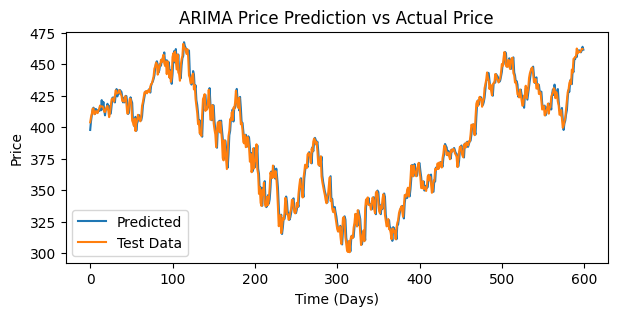

In [ ]:
# Extracting predictions
fig, ax = plt.subplots(figsize=(7, 3))
concat_data['Predicted_Price'].plot(ax=ax, label = "Predicted")
concat_data['Actual_Price'].plot(ax=ax, label = 'Test Data')
ax.legend()
plt.title('ARIMA Price Prediction vs Actual Price')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.show()

Reviewing the visualization, we find the ARIMA model demonstrates strong one step predictive performance. The orange line is the test data, whereas the blue line are the one-step model predictions. It is seen that the one-step predictions (blue line) traces well the actual test data. To quantify this prediction accuracy we will evaluate the model’s performance statistics.

## Baseline model evaluation

In [ ]:
# Creating SMAPE

# Define the function to return the SMAPE value
def calculate_smape(actual, predicted):

    # Convert actual and predicted to numpy
    # array data type if not already
    if not all([isinstance(actual, np.ndarray),
                isinstance(predicted, np.ndarray)]):
        actual, predicted = np.array(actual), np.array(predicted) # Corrected line

    return round(
        np.mean(
            np.abs(predicted - actual) /
            ((np.abs(predicted) + np.abs(actual))/2)
        )*100, 2
    )
  # Formula for this calcualtion was found here 'https://www.geeksforgeeks.org/python/how-to-calculate-smape-in-python/'

Checking for missingness prior to data evaluation

In [ ]:
# Checking for rows of NaN values
concat_data[concat_data['Actual_Price'].isna()==True]

,Predicted_Price,Actual_Price,Date
599,461.531823,NaN,NaT


In [ ]:
# Revewing the last five rows
concat_data.tail()

,Predicted_Price,Actual_Price,Date
595,460.353495,459.52,2023-11-27
596,459.435108,460.37,2023-11-28
597,460.844567,462.16,2023-11-29
598,463.806986,462.03,2023-11-30
599,461.531823,NaN,NaT


In [ ]:
# Dropping the out of sample prediction
concat_data.dropna(inplace=True)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error

# ARIMA predictions
arima_mse = mean_squared_error(concat_data['Actual_Price'], concat_data['Predicted_Price'])
arima_mae = mean_absolute_error(concat_data['Actual_Price'], concat_data['Predicted_Price'])
arima_rmae = root_mean_squared_error(concat_data['Actual_Price'], concat_data['Predicted_Price'])
arima_smape = calculate_smape(concat_data['Actual_Price'], concat_data['Predicted_Price'])

# Print ARIMA performance
print(f"ARIMA Performance:")
print(f"  MSE: {arima_mse:.6f}")
print(f"  RMSE: {arima_rmae:.6f}")
print(f"  MAE: {arima_mae:.6f}")
print(f"  SMAPE: {arima_smape:.6f}")


ARIMA Performance:
  MSE: 39.469818
  RMSE: 6.282501
  MAE: 4.874046
  SMAPE: 1.280000


Something to note prior to proceeding with performance evaluation is that the model performance statistics are, in fact, an aggregate of several ARIMA models. At each time step t, the ARIMA model produces a t+1 forecast. Later, the ARIMA model incorporates the next timestep in its training to predict the next timestep in the test dataset. Due to the ARIMA model architecture, one-step predictions need to be performed this way.  

Mathematically, the auto-regression function is defined $ y_t=C+\phi_1y_{t-1}+\phi_2y_{t-2}+...\phi_qy_{t-q}+\epsilon_t$, where \$y_t\$ is the outcome of interest which is predicted by q lagged features. The  moving average aspect is defined $y_t=C+\epsilon_t+\theta_1\epsilon_{t-1}+\theta_2\epsilon_{t-2}+...\theta_q\epsilon_{t-q}$. It is essentially a weighted average of the model’s past forecast errors, defined by $\epsilon_t$. Thus, in our model parameters, the order of the AR component and the MA component are specified, but as new data is added, the weights are constantly changing. One argument is that as new test data is added, the model weights or parameters become increasingly stabilized and do not change meaningfully. This is an assumption that is made in order to create one-step predictions. A potential alternative way of creating a fair comparison is to train the ARIMA model at the beginning of each trading week and use the model parameters to forecast the week's price action movements. Similarly, any comparison model will be trained at the beginning of each week in the test dataset, and its prediction will be recorded. The issue with this is the computational resources and time necessary to conduct such a “fair” comparison when working with multiple neural networks and performing heuristic or grid search hyperparameter tuning. The search space for an optimal model becomes large and a challenging task. For this reason, we will proceed with refitting the ARIMA model for each one-step forecast.

The performance statistics indicate that the one-step predictions of the aggregate ARIMA models are highly performant. Reviewing the conservative-based performance metric RMSE, we find that the model has an average prediction error of 6.28 price units. Less conservative estimates, such as MAE, reveal a smaller prediction error of 4.87 price units. The reason for this discrepancy is due to how the errors are computed. MSE always squares errors to prevent any error negation. Large errors are then penalized more than small errors due to the squaring term. When the square root of this metric is computed, it will be slightly more inflated than the MAE, which never applies any scaling to the errors.

The symmetric mean absolute percentage error (SMAPE) is included in the performance metrics to provide another intuitive perspective of model performance in terms of percentage error. SMAPE is chosen over MAPE due to its treatment of over- and under-forcasts in a relative way rather than an absolute way. For instance, a double over-estimation is treated equivalently as a half under-estimate with SMAPE, whereas MAPE treats them differently. This error difference is exacerbated in MAPE for large overestimates and underestimates. Reviewing the SMAPE reveals an average relative forecast error of 1.28%, indicating strong model predictive performance.

Overall, the aggregate ARIMA models show strong one-step predictions. Visualizing the one-step predictions, the model’s predictions were found to trace well the test data Vanguard ETF one-step price. The quantitative metrics performance statistics corroborated with the visualization, with low RMSE and minimal SMAPE, highlighting the ARIMA model’s strong predictive performance in one-step price predictions.






# Creating a Sentiment analysis model - Bert Model

To accomplish the task of sentiment analysis, a pretrained Bidirectional Encoder Representations from Transformers (BERT) model will be employed. BERT models are specially designed transformer models for NLP tasks such as text classification. The model is designed to understand the context of text using a bidirectional approach, focusing on capturing the relationship between words (GeeksforGeeks, 2026). This project will be employing the pre-trained Fin-BERT model available from HuggingFace. The model has been pre-trained on a financial text corpus and will be fine-tuned and adapted for new headline sentiment analysis.

## Notes

The below code was adapted from:
* https://www.codegenes.net/blog/hugging-face-pytorch-bert/

PyTorch was utilized instead of TensorFlow for various reasons. One major reason was a bug that prevented training a pre-trained Bert model via GPU. This made it significantly more burdensome for model training and evaluation. Another reason was that HuggingFace has a pre-train Bert model trained on financial text corpus, making it the most ideal model for this projects application. Unfortunately, the library that facilitates loading in HuggingFace models in TensorFlow was giving substantial hardship, in which PyTorch was resorted to for model training.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW

Reviewing data stucture and data preprocessing

In [ ]:
# Viewing dataframe structure
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [ ]:
# Creating mappings of the sentiment classes
X = df_sentiment['Sentence']
y = df_sentiment['Sentiment'].map({'negative':0,'neutral':1,'positive':2})

In [ ]:
# Mapping is correct
pd.concat([y,df_sentiment['Sentiment']],axis=1).head()

,Sentiment,Sentiment
0,2,positive
1,0,negative
2,2,positive
3,1,neutral
4,1,neutral


Creating train, validation, and test split

In [ ]:
# Creating a train, validation, and test set using a 70, 20, 10 split
from sklearn.model_selection import train_test_split

# Creating a train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)
# Splitting the test set into a validation set for model tuning
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.33, random_state=42)

Creating classes for pytorch model training

In [ ]:
# Define a custom dataset
class CustomDataset(Dataset):

    # Initialling the directory containing the data and its corresponding tokenizer and max length
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    # Returning the number of samples in the dataset
    def __len__(self):
        return len(self.texts)

    # Function loads and returns a sample from the dataset at a given index
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## Training initial pytorch model

Loading in the pretrained BERT model and tokenizer

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load pre - trained model tokenizer
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

# Load pre - trained model
model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert', num_labels=3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model training

In [ ]:
# Create dataset and dataloader
# Convert pandas Series to lists for positional indexing in CustomDataset
dataset_train = CustomDataset(X_train.tolist(), y_train.tolist(), tokenizer, max_length=128)
dataset_val = CustomDataset(X_val.tolist(), y_val.tolist(), tokenizer, max_length=128)
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=32, shuffle=True)

# Define optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Initializing the best validation loss
best_val_loss = float('inf')

# Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.train()
# Setting training patience to prevent overfitting
patience = 0
for epoch in range(15):
    if patience !=5:

      # Updating patience
      patience+=1
      print('Patience:', patience)

      # Instantiating loss and batch index
      total_loss = 0
      batch_i_train = 0
      for batch in dataloader_train:
          batch_i_train += 1
          input_ids = batch['input_ids'].to(device)
          attention_mask = batch['attention_mask'].to(device)
          labels = batch['labels'].to(device)

          # Extracting outputs
          outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

          # Computing loss and perfoming back-propagation
          loss = outputs.loss
          total_loss += loss
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()

      # Obtaining average loss for each batch
      avg_train_loss = total_loss / batch_i_train

      ## Validation step

      # Ensuring model is in evaluation mode
      model.eval()
      batch_i_val = 0
      total_loss_val = 0

      # Perfoming model evalaution for each batch in the validation set
      for batch in dataloader_val:
          batch_i_val +=1

          # Obtaining model inputs
          input_ids_val = batch['input_ids'].to(device)
          attention_mask_val = batch['attention_mask'].to(device)
          labels_val = batch['labels'].to(device)

          # Applying model inputs and computing model loss and adding it to total losss
          with torch.no_grad():
            val_outputs = model(input_ids_val, attention_mask=attention_mask_val, labels=labels_val)
            val_loss = val_outputs.loss
            total_loss_val += val_loss

      # Obtaining average loss for each batch
      avg_train_val = total_loss_val / batch_i_val

      # After each epoch
      if avg_train_val < best_val_loss:
        if epoch != 0:
          # Resetting patience
          print('Patience reset')
          patience=0

        # Updating model weights
        print('Saving new weights')
        best_val_loss = avg_train_val
        torch.save(model.state_dict(), 'best_model_weights.pth')

      # Printing informative epoch stats
      print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_train_val:.4f}')

      # If patience is exceeded
    else:
      break

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Patience: 1
Saving new weights
Epoch 1, Train Loss: 0.8506, Val Loss: 0.5451
Patience: 2
Patience reset
Saving new weights
Epoch 2, Train Loss: 0.3935, Val Loss: 0.3976
Patience: 1
Epoch 3, Train Loss: 0.2131, Val Loss: 0.4082
Patience: 2
Epoch 4, Train Loss: 0.1526, Val Loss: 0.4905
Patience: 3
Epoch 5, Train Loss: 0.1421, Val Loss: 0.5869
Patience: 4
Epoch 6, Train Loss: 0.1353, Val Loss: 0.5604
Patience: 5
Epoch 7, Train Loss: 0.1206, Val Loss: 0.5899


Utilized AI to obtain raw scores and applying softmax function. I applied the loop and stored predictions in dictionary

In [ ]:
# Loading the best perfoming model
model.load_state_dict(torch.load('best_model_weights.pth'))

<All keys matched successfully>

## Obtaining model predictions

In [ ]:
import torch.nn.functional as F

# Creating an empty list to store results
predictions = []
i=0 # creating an index for each test record
for row in X_test:

  # The raw scores from the model
  input = tokenizer.encode(X_test.iloc[i], return_tensors='pt').to(device)
  output = model(input)
  logits = output.logits

  # Apply softmax along the last dimension (classes) to get probabilities
  probabilities = F.softmax(logits, dim=-1)
  predicted_class = torch.argmax(probabilities, dim=-1)

  # Appending model predictions
  predictions.append(predicted_class.cpu().numpy()[0])
  i+=1


## Initial - Model Evaluation

In [ ]:
from sklearn import metrics

# Evaluating balance accruacy
print(metrics.balanced_accuracy_score(y_test, predictions)) # More reliable metric as classes are imbalanced

0.7284206316462507


In [ ]:
from sklearn.metrics import classification_report

# Creating classification report
target_names = ['negative', 'neutral', 'positive']
print(classification_report(y_test, predictions, target_names=target_names))

              precision    recall  f1-score   support

    negative       0.55      0.45      0.49       191
     neutral       0.82      0.90      0.86       612
    positive       0.90      0.84      0.87       371

    accuracy                           0.81      1174
   macro avg       0.76      0.73      0.74      1174
weighted avg       0.80      0.81      0.80      1174



Reviewing the performance statistics reveals deep insights into our model's performance and possible next steps to improve its discriminatory ability. As mentioned during the data profiling, the dataset is meaningfully imbalanced, with negative news stories having the least frequency of all classes. This imbalance seems to be reflected in our model performance, where the negative class has very poor performance. For instance, the balanced accuracy of the overall model is 72%. Diving deeper into the model's performance and reviewing the class recall (the composition of the balanced accuracy), we find what is hampering performance. The recall for the negative class is 0.45, meaning that of all the true positive negative instances, on 45% are being correctly classified.  The neutral class has a meaningfully better recall at 0.90, followed by the positive class at 0.84.

The class precision provides another dimension of class performance. A similar theme is seen where the negative class is the lowest performer with a precision of 0.55. This means that of those negative predictions made by the model, only 55% of them were correct. This conveys high unreliability for negative class predictions, which will need to be addressed prior to creating our sequential time series model. This is because a low-performing sentiment analysis model will likely add additional noise to a time series model, making it difficult to detect meaningful patterns from the data.  

To address this, two methods may be deployed to augment the negative and neutral classes. This can be done via a rules-based method using regex commands or using an LLM to generate new negative and neural news titles, similar to those of the dataset. The latter has the benefit of being easier to implement and creating semantically meaningful news titles. The quality of this generated data may present challenges for model training, which will be considered during model evaluation. Rules-based approaches have the benefit of allowing for more autonomy in the data generation process. Although it is more laborious, as one has to correctly create regex commands that have only the intended actions. We will attempt to generate new data via an LLM to see if this improves model performance for the imbalanced labels.




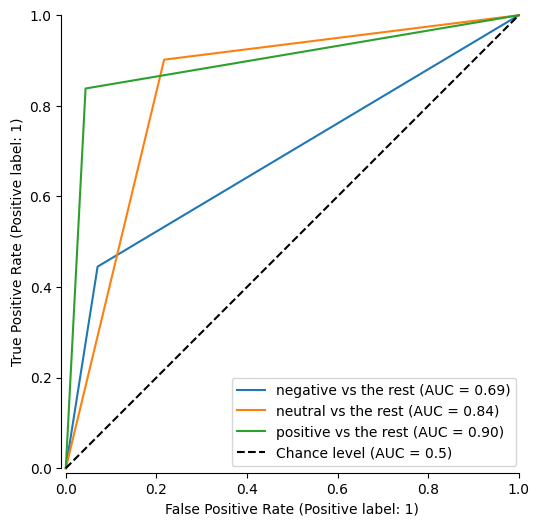

In [ ]:
# Creating a AUC curve
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay
lb = LabelBinarizer()
lb.fit(y_test)
binarized_labels_true = lb.transform(y_test)
binarized_labels = lb.transform(predictions)


# Extracting class names
class_names = ['negative', 'neutral', 'positive']

fig, ax = plt.subplots(figsize=(6, 6))

# Creating a ROC curve for the negative class
RocCurveDisplay.from_predictions(
  binarized_labels_true[:,0],
  binarized_labels[:,0],
  name=f'{class_names[0]} vs the rest',
  ax=ax,
  despine=True
)

# Creating a ROC curve for the neutral class
RocCurveDisplay.from_predictions(
  binarized_labels_true[:,1],
  binarized_labels[:,1],
  name=f'{class_names[1]} vs the rest',
  despine=True,
  ax=ax
)

# Creating a ROC curve for the positive class
RocCurveDisplay.from_predictions(
  binarized_labels_true[:,2],
  binarized_labels[:,2],
  name=f'{class_names[2]} vs the rest',
  despine=True,
  plot_chance_level = True,
  ax=ax
)

# Displaying results
plt.show()

Overall, the ROC curve shows that the model is of adequate quality with heterogeneous discriminatory performance. The AUC statistics for the ‘positive’, ‘neutral’, and ‘negative’ classes are 0.90, 0.84, and 0.69, respectively. Across classification thresholds, the model demonstrates strong discriminatory performance for the positive class. Across thresholds its discriminatory ability diminishes for the neutral and negative classes, likely due to the lack of class representation. To address this, data augmentation strategies described above will be performed to address this class imbalance and improve the overall quality of the classifier.

# Performing data augmentation

Loading LLM model

In [ ]:
# Load model directly
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Loading pretrained model
torch.random.manual_seed(0)
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto"
)

# Loading model tokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

# Creating pipline necessary for text generation
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [ ]:
# Printing a sample news title
df_sentiment[df_sentiment['Sentiment']=='negative']['Sentence'].iloc[0]

'$ESI on lows, down $1.50 to $2.50 BK a real possibility'

Creating a test prompt and evaluating response

In [ ]:
# Establishing generation arguments
generation_args = {
    "max_length": 10000, # Use max_length instead of max_new_tokens to avoid warning
    "return_full_text": False,
    "temperature": 0.2,
    "do_sample": True,
}

# Creating role prompts, and content prompts
messages = [
    {"role": "system", "content": "You are a sentiment analysis sentence data augmentor. "}, # Role prompt
    {"role": "user", "content": "Generate 10 financial negative news title. Similar in structure to the example provided."}, # Content prompt
    {"role": "user", "content": "$ESI on lows, down $1.50 to $2.50 BK a real possibility"}, # Passing an example
]

# Generating responses
output = pipe(messages, **generation_args)

# Extracting generated responses
x = output[0]['generated_text']

# Printing output
print(x)

Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=10000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 1. $ESI plunges, now trading at $2.50, down $1.50 - Bears in control
2. $ESI tumbles $1.50, now at $2.50, bearish trend intensifies
3. $ESI hits $2.50, down $1.50, bear market looms
4. $ESI drops $1.50, now $2.50, investors fearful of a downturn
5. $ESI sinks $1.50, now $2.50, bearish sentiment on the rise
6. $ESI falls $1.50, now $2.50, market analysts predict a bearish phase
7. $ESI drops $1.50, now at $2.50, bearish momentum gains ground
8. $ESI plummets $1.50, now $2.50, bearish outlook for the market
9. $ESI declines $1.50, now $2.50, bearish trend continues
10


In [ ]:
# Viewing value counts
df_sentiment['Sentiment'].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


Preprocessing for negative new title generation

In [ ]:
# Obtaining number of negative examples to generate
num_negative_examples = 3130-860 # Total examples to match neutral class
num_negative_iter = round((num_negative_examples/1.5)/10) # Scaling to reduce the number of 10 batch examples to generate

In [ ]:
# Creating an empty dictionary to store
data = {'Sentiment':[], 'Sentence':[], 'index':[]}

# Creating negative example dataframe
neg_examples = df_sentiment[df_sentiment['Sentiment']=='negative']['Sentence'].reset_index(drop=True)

Creating loop for text generation

In [ ]:
import regex as re
for ex in range(num_negative_iter):

  # Generating a random index to sample
  index = np.random.randint(0,len(neg_examples))

  # Setting prompts
  messages = [
    {"role": "system", "content": "You are a sentiment analysis sentence data augmentor. "},
    {"role": "user", "content": "Generate 10 financial negative news title."},
    {"role": "user", "content": re.sub(r'\s\W', '',neg_examples[index])},]

  # Generating output
  output = pipe(messages, **generation_args)
  x = output[0]['generated_text']

  # Small data preprocessing
  list_of_lines = [re.sub(r'\d\W','', line).strip() for line in x.splitlines() if line.strip()]
  list_of_lines = [re.sub(r'\\','', line) for line in list_of_lines]
  list_of_lines = [re.sub(r'^1','', line) for line in list_of_lines]

  # Adding information to dictionary
  for item in list_of_lines:
    data['Sentiment'].append('negative')
    data['Sentence'].append(item)
    data['index'].append(index)

Both `max_new_tokens` (=256) and `max_length`(=10000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=10000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=10000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=10000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Model output evaluations

In [ ]:
# Reviewing sentence generation
data['Sentence'][0:20]

['"BHP Billiton\'s Dividend Cut Sends FTSE into a Downward Spiral"',
 '"FTSE Tumbles as BHP Billiton Announces Dividend Reduction"',
 '"BHP Billiton\'s Dividend Slash Hits FTSE Hard"',
 '"FTSE Falls on BHP Billiton\'s Dividend Cut Announcement"',
 '"BHP Billiton\'s Dividend Cut Triggers FTSE Decline"',
 '"FTSE Tumbles Following BHP Billiton\'s Dividend Cut"',
 '"BHP Billiton\'s Dividend Cut Sends FTSE into Freefall"',
 '"FTSE Tumbles as BHP Billiton Slashes Dividend"',
 '"BHP Billiton\'s Dividend Cut Sends FTSE into a Downward Spiral"',
 ' "FTSE Falls on BHP Billiton\'s Dividend Cut Announcement"',
 '"BHP Billiton\'s Dividend Cut Sends FTSE into the Red"',
 '"FTSE Tumbles as BHP Billiton Announces Dividend Slash"',
 '"BHP Billiton\'s Dividend Reduction Puts FTSE Under Pressure"',
 '"FTSE Falls as BHP Billiton Cuts Dividend Amid Economic Uncertainty"',
 '"BHP Billiton\'s Dividend Cut Triggers FTSE Decline"',
 '"FTSE Tumbles Following BHP Billiton\'s Dividend Cut Announcement"',
 '"BHP B

In [ ]:
# Obtaining index for first example
data['index'][0]

204

In [ ]:
# Reviewing the original news article
neg_examples[204]

'BHP Billiton drags FTSE lower after slashing dividend'

In [ ]:
# Removing news titles that were cut off
sentences = []

for news in data['Sentence']:
  if len(news) > 50:
    sentences.append(news)

# Removing unnecessary quotations
sentences = [re.sub(r'"','', line) for line in sentences]

In [ ]:
# Reviewing first 10 rows
sentences[0:10]

["BHP Billiton's Dividend Cut Sends FTSE into a Downward Spiral",
 'FTSE Tumbles as BHP Billiton Announces Dividend Reduction',
 "FTSE Falls on BHP Billiton's Dividend Cut Announcement",
 "BHP Billiton's Dividend Cut Triggers FTSE Decline",
 "FTSE Tumbles Following BHP Billiton's Dividend Cut",
 "BHP Billiton's Dividend Cut Sends FTSE into Freefall",
 "BHP Billiton's Dividend Cut Sends FTSE into a Downward Spiral",
 " FTSE Falls on BHP Billiton's Dividend Cut Announcement",
 "BHP Billiton's Dividend Cut Sends FTSE into the Red",
 'FTSE Tumbles as BHP Billiton Announces Dividend Slash']

In [ ]:
# Creating cleaned data
data_cleaned = {'Sentiment':[], 'Sentence':[]}

# Creating new data with cleaned sentences
for sentence in sentences:
  data_cleaned['Sentiment'].append('negative')
  data_cleaned['Sentence'].append(sentence)

In [ ]:
# Creating new dataframe
aug_neg = pd.DataFrame(data_cleaned)

In [ ]:
# Reviewing
aug_neg.head(15)

,Sentiment,Sentence
0,negative,BHP Billiton's Dividend Cut Sends FTSE into a ...
1,negative,FTSE Tumbles as BHP Billiton Announces Dividen...
2,negative,FTSE Falls on BHP Billiton's Dividend Cut Anno...
3,negative,BHP Billiton's Dividend Cut Triggers FTSE Decline
4,negative,FTSE Tumbles Following BHP Billiton's Dividend...
5,negative,BHP Billiton's Dividend Cut Sends FTSE into Fr...
6,negative,BHP Billiton's Dividend Cut Sends FTSE into a ...
7,negative,FTSE Falls on BHP Billiton's Dividend Cut Ann...
8,negative,BHP Billiton's Dividend Cut Sends FTSE into th...
9,negative,FTSE Tumbles as BHP Billiton Announces Dividen...


Appending augmented data to dataframe

In [ ]:
# Creating an augmented dataset
data_aug = pd.concat([df_sentiment, aug_neg])

In [ ]:
data_aug['Sentiment'].value_counts(normalize=True)

,proportion
Sentiment,
neutral,0.440907
negative,0.298211
positive,0.260882


## Retraining sentiment model

Creating test and validation sets without data augmentation

In [ ]:
# Creating mappings of the sentiment classes
X = df_sentiment['Sentence']
y = df_sentiment['Sentiment'].map({'negative':0,'neutral':1,'positive':2})

# Creating a train, validation, and test set using a 70, 20, 10 split
from sklearn.model_selection import train_test_split

# Creating a test set - Not including augmented text
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)
# Splitting the test set into a validation set for model tuning - Not including augmented text
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.33, random_state=42)

Creating training sets with data augmentation

In [ ]:
X = data_aug['Sentence']
y = data_aug['Sentiment'].map({'negative':0,'neutral':1,'positive':2})

# Training with augmented text
X_train, _ , y_train, _ = train_test_split( # We want to keep constant the test dataset to avoid biased performance statistics
    X, y, test_size=0.30, random_state=42)



Model retraining

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
# Load pre - trained model tokenizer
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

# Load pre - trained model
model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert', num_labels=3)

# Create dataset
dataset_train = CustomDataset(X_train.tolist(), y_train.tolist(), tokenizer, max_length=128)
dataset_val = CustomDataset(X_val.tolist(), y_val.tolist(), tokenizer, max_length=128)

# Create dataloader
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=32, shuffle=True)

# Define optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Initializing the best validation loss
best_val_loss = float('inf')

# Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.train()

# Setting training patience to prevent overfitting
patience = 0
for epoch in range(15):
    if patience !=5:

      # Updating patience
      patience+=1
      print('Patience:', patience)

      # Instantiating loss and batch index
      total_loss = 0
      batch_i_train = 0

      # Performing forward pass in batches
      for batch in dataloader_train:
          batch_i_train += 1

          # Obtaining model inputs
          input_ids = batch['input_ids'].to(device)
          attention_mask = batch['attention_mask'].to(device)
          labels = batch['labels'].to(device)

          # Extracting model output
          outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

          # Computing loss and adding to total loss
          loss = outputs.loss
          total_loss += loss

          # Perfoming backpropagation and updating weights
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()

      # Obtaining average loss for each batch
      avg_train_loss = total_loss / batch_i_train

      # Validation step
      model.eval()
      batch_i_val = 0
      total_loss_val = 0

      # Performing model evaluation on validation dataset
      for batch in dataloader_val:
          batch_i_val +=1

          # Gathing model inputs
          input_ids_val = batch['input_ids'].to(device)
          attention_mask_val = batch['attention_mask'].to(device)
          labels_val = batch['labels'].to(device)

          # Computing loss and adding it to total loss
          with torch.no_grad():
            val_outputs = model(input_ids_val, attention_mask=attention_mask_val, labels=labels_val)
            val_loss = val_outputs.loss
            total_loss_val += val_loss

      # Obtaining average loss for validation batches
      avg_train_val = total_loss_val / batch_i_val

      # Updating best loss metric if average loss is less than best loss
      if avg_train_val < best_val_loss:
        if epoch != 0:
          # Resetting patience
          print('Patience reset')
          patience=0

        # Saving model weights
        print('Saving new weights')
        best_val_loss = avg_train_val
        torch.save(model.state_dict(), 'best_model_weights.pth')

      # Printing informative epoch stats
      print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_train_val:.4f}')

      # If patience is exceeded
    else:
      break

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Patience: 1
Saving new weights
Epoch 1, Train Loss: 0.6794, Val Loss: 0.4189
Patience: 2
Patience reset
Saving new weights
Epoch 2, Train Loss: 0.2894, Val Loss: 0.2990
Patience: 1
Epoch 3, Train Loss: 0.1649, Val Loss: 0.3067
Patience: 2
Epoch 4, Train Loss: 0.1255, Val Loss: 0.3416
Patience: 3
Epoch 5, Train Loss: 0.1145, Val Loss: 0.3427
Patience: 4
Epoch 6, Train Loss: 0.1015, Val Loss: 0.4302
Patience: 5
Epoch 7, Train Loss: 0.0982, Val Loss: 0.4644


Loading best learned weights

In [ ]:
# Loading best model weights
model.load_state_dict(torch.load('best_model_weights.pth'))

<All keys matched successfully>

Extracting test predictions

In [ ]:
import torch.nn.functional as F

# Creating empty list to store predictions
predictions = []
i=0
for row in X_test:

  # The raw scores from the model
  input = tokenizer.encode(X_test.iloc[i], return_tensors='pt').to(device)
  output = model(input)
  logits = output.logits

  # Apply softmax along the last dimension (classes) to get probabilities
  probabilities = F.softmax(logits, dim=-1)
  predicted_class = torch.argmax(probabilities, dim=-1)

  # Appending predictions
  predictions.append(predicted_class.cpu().numpy()[0])

  # Updating index
  i+=1

## Model evaluation - Model 2

In [ ]:
# Viewing balance accuracy
from sklearn import metrics
print(metrics.balanced_accuracy_score(y_test, predictions))

0.8130457095742903


In [ ]:
from sklearn.metrics import classification_report

# Reviewing confusion matrix
target_names = ['negative', 'neutral', 'positive']
print(classification_report(y_test, predictions, target_names=target_names))

              precision    recall  f1-score   support

    negative       0.63      0.62      0.63       191
     neutral       0.88      0.87      0.88       612
    positive       0.92      0.95      0.93       371

    accuracy                           0.86      1174
   macro avg       0.81      0.81      0.81      1174
weighted avg       0.85      0.86      0.85      1174



Data augmentation of the negative class improved its representation and the model’s overall performance. The holistic balanced accuracy metric is 81.30%, representing an approximate 11% improvement over the baseline sentiment analysis model. Evaluating the class-specific performance metrics reveals informative performance statistics regarding the impact of data augmentation. Revealing the negative sentiment class reveals a meaningful improvement in class classification performance. The F1-score, or the harmonic mean between precision and recall, improved to 0.63 from 0.49. Indicating that the text generation improved both the precision and recall of the model. Reviewing the negative class precision, we find that given a negative prediction, the model correctly classifies negative 63% of observations in the test dataset. This is a slight improvement over the baseline precision level of 55%. In addition, the negative class recall has improved to 0.62 from 0.45, indicating the model is capturing more true negative instances.

The model performance for the other two classes appears to have improved from the data augmentation. The precision and recall for the positive class are 0.92 and 0.95, respectively. These metrics are both improvements from the baseline precision and recall metrics of 0.90 and 0.84, respectively. This consequently led to a slight increase in the F1-score for this class, now at 0.93. With regards to the neutral class, overall, there has been an increase in predictive performance given by the F1-score of 0.88 from 0.86 baseline levels. The precision for the neutral class fell slightly to 0.88 from 0.82, however, the model now captures more true instances of neutral new headlines, given by the 0.90 recall.

Overall, the data augmentation did improve model performance. The balanced accuracy increased by 11% from its initial baseline levels. Diving into the class specific perfonamce metrics reveals that overall, all the classes did experience improvements in text classification after data augmentation. In particular, the negative class experienced slight improvements, but did not reach nearly the performance experienced by the positive and neutral classes. This is a limitation that will need to be considered moving forward when generating the sentiment predictions of the financial news headlines dataset and ultimately, multivariate sequential modeling.


Creating ROC curve

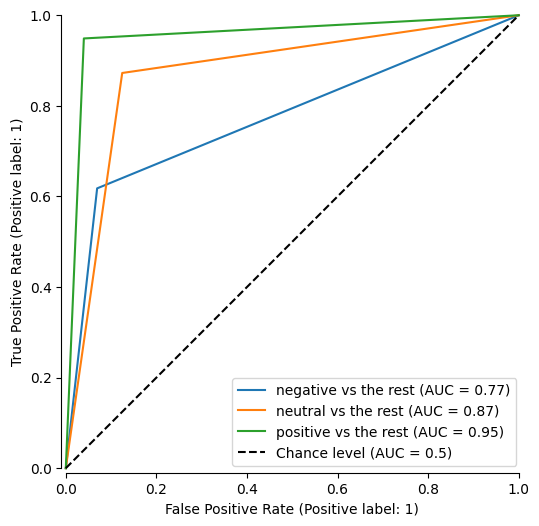

In [ ]:
# Creating a AUC curve
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay

# Fitting label binarizer
lb = LabelBinarizer()
lb.fit(y_test)
binarized_labels_true = lb.transform(y_test)
binarized_labels = lb.transform(predictions)

# Extracting class names
class_names = ['negative', 'neutral', 'positive']

fig, ax = plt.subplots(figsize=(6, 6))

# ROC curve for negative class
RocCurveDisplay.from_predictions(
  binarized_labels_true[:,0],
  binarized_labels[:,0],
  name=f'{class_names[0]} vs the rest',
  ax=ax,
  despine=True
)

# ROC curve for neutral class
RocCurveDisplay.from_predictions(
  binarized_labels_true[:,1],
  binarized_labels[:,1],
  name=f'{class_names[1]} vs the rest',
  despine=True,
  ax=ax
)

# ROC curve for positive class
RocCurveDisplay.from_predictions(
  binarized_labels_true[:,2],
  binarized_labels[:,2],
  name=f'{class_names[2]} vs the rest',
  despine=True,
  plot_chance_level = True,
  ax=ax
)

# Displaying curve
plt.show()

Reviewing the ROC curve reveals informative information regarding the quality of the classifier. The discrimination ability of the classifier across classification thresholds improved meaningfully for the negative class. The AUC statistic is 0.77, indicating good discrimination quality for the negative class. The discrimination quality across the thresholds for all other classes is very strong. The AUC for the neutral and the positive class is 0.87 and 0.95, respectively. These AUC metrics are slight improvements from baseline classification statistics.

# Creating news sentiment inputs for sequential modeling

Applying sentiment model to the financial news headlines in our news dataset. These predictions will be then be aggregated by date to gather average daily news sentiment. The inputs will then be passed to a neural network along with price data to generate next time step predictions.

In [ ]:
# Filtering news dataset
df_news_filt = df_news[(df_news['Date'] >= '2016-01-05')
                     & (df_news['Date'] < '2023-12-01')]

Applying sentiment model to the news dataset

In [ ]:
import torch.nn.functional as F

# Creating an empty list to store results
predictions = []
i=0
for row in df_news_filt['Article_title']:

  # The raw scores from the model
  input = tokenizer.encode(df_news_filt['Article_title'].iloc[i], return_tensors='pt').to(device)
  output = model(input)
  logits = output.logits

  # Apply softmax along the last dimension (classes) to get probabilities
  probabilities = F.softmax(logits, dim=-1)
  predicted_class = torch.argmax(probabilities, dim=-1)

  # Appending predictions
  predictions.append(predicted_class.cpu().numpy()[0])
  i+=1

Revewing model predictions

In [ ]:
# Reviewing predictions
predictions[0:15]

[np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(0)]

{'negative':0,'neutral':1,'positive':2}

In [ ]:
# Concatinating the predictions and the news headlines for prediction evluation
df_news_combined = pd.concat([df_news_filt.reset_index(drop=True), pd.Series(predictions)], axis=1)

# Renaming columns
df_news_combined.rename(columns={0:'predictions'},inplace=True)

# Selecting columns
df_news_combined = df_news_combined.iloc[:,1:]

Quality check

In [ ]:
# Reviewing the predictions
for row in df_news_combined.iloc[0:15,:].iterrows():
  print(row[1][1], row[1][4] )

UK antitrust regulator wins appeal over Apple probe 0
Japan aircon king Daikin looks to custom chips for energy savings 2
Judge set to rule on Berkshire Hathaway request for speedy trial over Pilot unit 0
Analysts predict more brands will flee X after Musk tirade 0
Netflix (NFLX) to Offer Grand Theft Auto Trilogy in December 2
Bull Market Buys: 3 Exciting Growth Stocks to Own for the Long Run 2
Could Investing in the Nasdaq-100 Help You Retire a Millionaire? 2
Guru Fundamental Report for AAPL 1
GRAPHIC-ChatGPT one year on: From viral AI bot to OpenAI's boardroom battle 2
Here's My Top "Magnificent Seven" Stock to Buy Right Now 2
The Nasdaq-100 Is Up 47% in 2023, but This Artificial Intelligence (AI) Stock Is Doing Even Better 2
2 Warren Buffett Stocks That Could Roar Higher in the Next Bull Market 2
3 Unstoppable Growth Stocks to Buy if There's a Stock Market Sell-Off 2
US STOCKS-S&P 500 ends lower on mixed Fed messages, PCE on deck 0
US STOCKS-S&P 500 wobbles to lower close on mixed F

/tmp/ipykernel_2164/808942336.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(row[1][1], row[1][4] )


Predictions appear appropriate

In [ ]:
# Saving predictions
df_news_combined.to_csv('Model_predictions_news.csv')

## Exporting the model

In [ ]:
# Preprocessing the news data
input = CustomDataset(df_news_filt['Article_title'], y_train.tolist(), tokenizer, max_length=128)
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

In [ ]:
# Encoding the news data
input = tokenizer.encode(df_news_filt['Article_title'].tolist(), return_tensors='pt', padding=True, truncation=True).to(device)

In [ ]:
from torch.export import export

# Export to TorchScript
exported = export(model, (input,))
torch.export.save(exported, "model.pt")

W0426 18:01:17.509000 2164 torch/export/pt2_archive/_package.py:686] Expect archive file to be a file ending in .pt2, or is a buffer. Instead got {model.pt}


In [ ]:
# Creating aggregated dataset
data_agg = df_news_combined.groupby('Date')['predictions'].mean()

# Exporting aggregated data
data_agg.to_csv('Daily_news_sentiment.csv')

# Creating sequential model

## Creating multivariate timeseries

In [ ]:
# Obtaining news predictions and creating a dataframe
loc = '/content/drive/MyDrive/Spring 2026/Deep Learning Project 2/Model_predictions_news_3.csv'

df_news_combined = pd.read_csv(loc)

News sentiment predictions will be aggregated by day to get the daily average sentiment

In [ ]:
# Creating a groupby dataframe
data_agg = df_news_combined.groupby('Date')['predictions'].mean()

In [ ]:
# Obtaining the price data
df_time = df.iloc[:,0:2]
df_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1997 non-null   datetime64[ns]
 1   Price   1997 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 31.3 KB


Merging the price data with the average daily sentiment dataframe

In [ ]:
# Resetting index
data_agg = data_agg.reset_index()

In [ ]:
# Converting date to data time object
data_agg['Date'] = pd.to_datetime(data_agg['Date'])

In [ ]:
# Revewing dataframe
data_agg.head()

,Date,predictions
0,2016-01-05 00:00:00+00:00,1.473684
1,2016-01-06 00:00:00+00:00,1.363636
2,2016-01-07 00:00:00+00:00,1.545455
3,2016-01-08 00:00:00+00:00,2.000000
4,2016-01-09 00:00:00+00:00,0.000000


Need to remove the timezone component

In [ ]:
# Removing timezone component
data_agg = data_agg.set_index('Date').tz_convert(tz=None).reset_index()

In [ ]:
# Revewing removal of timezone component
data_agg.head()

,Date,predictions
0,2016-01-05,1.473684
1,2016-01-06,1.363636
2,2016-01-07,1.545455
3,2016-01-08,2.000000
4,2016-01-09,0.000000


In [ ]:
# Merging the dataframes
multi_var_time = pd.merge(data_agg,df_time, on='Date', how='inner')

In [ ]:
# Revewing merged result
multi_var_time.head()

,Date,predictions,Price
0,2016-01-05,1.473684,106.10
1,2016-01-06,1.363636,104.66
2,2016-01-07,1.545455,101.29
3,2016-01-08,2.000000,100.42
4,2016-01-11,1.250000,100.91


Reveiewing the number of dates (rows) in the new merged dataframe match the original Vanguard price dataframe

In [ ]:
multi_var_time.shape

(1996, 3)

In [ ]:
df_time.shape

(1997, 2)

Merge was successful

## Creating sliding window function

In [ ]:
data = multi_var_time.drop(columns='Date')

In [ ]:
# Scaling data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [ ]:
# Creating a sliding window function
def sliding(data, window):
  X = []
  y = []

  for i in range(len(data) - window):
    X.append(data[i:i+window])
    y.append(data[i+window,1])

  return np.array(X),np.array(y)

In [ ]:
X,y=sliding(data_scaled, 30)

## Creating a test and train split (validation will be handled directly by tensorflows validation split)

In [ ]:
# Creating a train, test split
split = int(0.70 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Creating sequential model

In [ ]:
# Revewing data shape
X_train.shape # 1376 time steps, 30 observations within each set, and 2 features (Price, Daily Average Sentiment)

(1376, 30, 2)

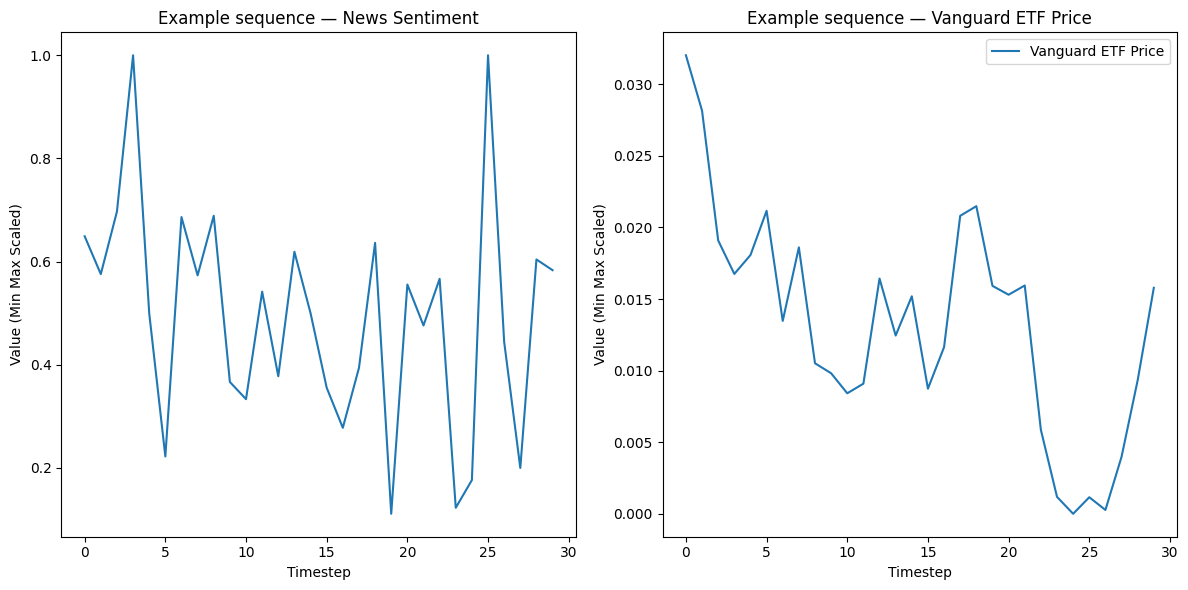

In [ ]:
sample = X_train[0]  # shape (30, 2)
t = np.arange(X_train.shape[1])

# Creating figure
plt.figure(figsize=(12,6))

# News sentiment plot
plt.subplot(1,2,1)
plt.plot(t, sample[:, 0], label=f'News Sentiment')
plt.xlabel('Timestep')
plt.ylabel('Value (Min Max Scaled)')
plt.title(f'Example sequence — News Sentiment')

# Vanguard ETF Price plot
plt.subplot(1,2,2)
plt.plot(t, sample[:, 1], label=f'Vanguard ETF Price')
plt.xlabel('Timestep')
plt.ylabel('Value (Min Max Scaled)')
plt.title(f'Example sequence — Vanguard ETF Price')

# Additional plot functions
plt.legend()
plt.tight_layout()
plt.show()

Above is a visualization of the first time step (timestep=0), which includes a 30-day window of daily news sentiment and Vanguard ETF price observations. On the left-hand side, we have the aggregated news sentiment predictions, which experience high overall volatility. Although useful information can be extracted upon closer inspection, alongside the Vanguard ETF price.

The news sentiment predictions appear to be a leading indicator of future price movement, with values above 0.80 and below 0.20 indicative of future price movement. For instance, at the beginning of the sequence, the daily news sentiment prediction approximately reached 1.0 before the fifth timestep. Looking at the Vanguard ETF price at this time, a trough, or a low, was formed around timeset 3. After the news sentiment value reached 1.0, the price rallied slightly, creating a lower high before falling into a range seen in timesteps 5-20. Around timeset 20, the daily news sentiment reaches a low of <0.20. After this low price followed by a meaningful push downwards to <0.005 levels. Finally, the daily news sentiment predictions reached levels of 1.0, where the price shortly rallied after. Therefore, the news sentiment predictions can be utilized much like modern technical analysis tools, such as the RSI and stochastic indicator, in that there are certain levels and patterns to be aware of to give an edge in future market price predictions. Using an end-to-end neural network, it is not necessary to specify how to best utilize the tool. Rather, the model will learn meaningful patterns and key levels that are most informative in predicting future price movements.


Correlation analysis - Below is a sample of a pairwise time-average statistics for each feature. This can be utilized to perform a correlation analysis

In [ ]:
# Pairwise time-average stats
X_train.mean(axis=1)[0:2]

array([[0.49451478, 0.01322094],
       [0.48954402, 0.01262313]])

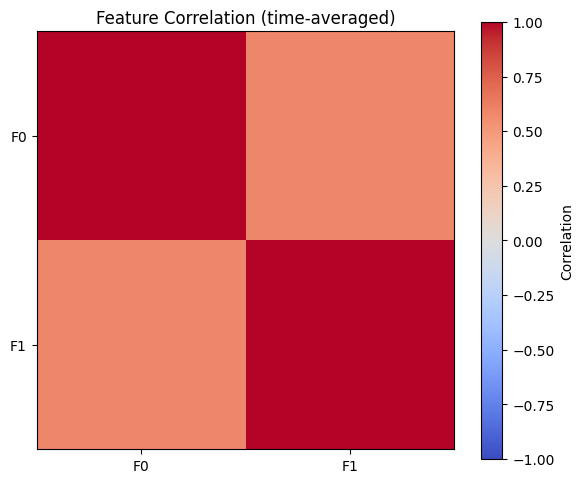

In [ ]:
# Time-averaged features per sample
x_train_avg = X_train.mean(axis=1)  # shape (N_train, 2)
corr = np.corrcoef(x_train_avg, rowvar=False)
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Feature Correlation (time-averaged)')
plt.xticks(range(2), [f'F{i}' for i in range(2)], rotation=0)
plt.yticks(range(2), [f'F{i}' for i in range(2)])
plt.tight_layout()
plt.show()


The following plot is a time-averaged correlation plot for the sentiment and Vanguard ETF price. Essentially, each timestep contains 30 time observations. The average value of each feature for these 30 time observations is obtained. This is repeated for each 30-day window timestep in the tensor. Finally, these pairwise aggregated statistics are then used to perform a correlation analysis.

The heatmap above demonstrates a positive relationship between the Vanguard ETF price and the daily news sentiment. This is in line with what we intuitively would expect and what was seen in the previous visualization. That is, as news sentiment increases, so does price action for the Vanguard ETF. Conversely, when the price goes down, news sentiment also experiences a downturn.


# Model - 1 GRU model

Gated recurrent unit networks (GRU) are a type of recurrent neural network that employs the use of forget gates and reset gates. GRUs use a simplified modeling architecture compared to that of LSTM networks. The modeling architecture solves the vanishing gradient problem persistent in RNN, while requiring fewer modeling parameters than those of the LSTM networks. This simplified modeling architecture will be beneficial in this project, considering that the multivariate dataset only contains 1376 examples to train from.

In [ ]:
from keras.layers import Input, GRU, Dense, Dropout

# Creaing symbolic tensors
inputs = Input(shape=(X_train.shape[1], X_train.shape[2])) # (Sliding Window, Number of Features)

# Creating GRU units
x = GRU(128)(inputs)

# Creating dense layer and applying dropout
x = Dense(128, activation='relu')(x)
x = Dropout(0.05)(x)
output = Dense(1)(x)

# Creaing model
model = keras.models.Model(inputs, output)

# Printing model summary
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,329 (263.00 KB)

 Trainable params: 67,329 (263.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Creating callbacks
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop after 5 epochs with no improvement
    min_delta=0.001,     # Minimum change to qualify as improvement
    verbose=2,           # Display messages when callback takes action
    restore_best_weights=True # Restore weights from the best epoch
)

# Creating callback to reduce the learning rate
from keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', # Metric to monitor
    factor=0.2,         # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=5,         # Number of epochs with no improvement
    min_lr=0.0001,      # Lower bound on the learning rate
    verbose=1
)

## Model training

In [ ]:
# Compiling model
model.compile(loss='mse', optimizer='adam', metrics=['mae'] )

In [ ]:
# Fitting model
history = model.fit(x=X_train,y=y_train, epochs= 50, validation_split=0.20, batch_size=64, callbacks=[early_stopping, reduce_lr])

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0133 - mae: 0.0875 - val_loss: 0.0296 - val_mae: 0.1646 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - mae: 0.0250 - val_loss: 3.7750e-04 - val_mae: 0.0154 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1749e-04 - mae: 0.0156 - val_loss: 0.0042 - val_mae: 0.0603 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3016e-04 - mae: 0.0136 - val_loss: 0.0025 - val_mae: 0.0449 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.1320e-04 - mae: 0.0133 - val_loss: 0.0026 - val_mae: 0.0449 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3866e-04 - mae: 0.0115 - val_loss: 0.0020 - val_mae: 0.0389 - learning_rate: 0.0010
Epoch 7/50
11/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2151e-04 - mae: 0.0112 
Epoch 7: ReduceLROnPlateau reducing learning rate 

In [ ]:
# Extracting model stats
r_loss, r_mae = model.evaluate(X_test, y_test, verbose=0)
print(f'GRU — Test mae: {r_mae:.3f} | Loss: {r_loss:.3f}')
print('GRU params:', model.count_params())


GRU — Test mae: 0.022 | Loss: 0.001
GRU params: 67329


In [ ]:
# Extracting model predictions
pred = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
# Converting scaled test data back to original units
y_test_inv = scaler.inverse_transform(
    np.c_[np.zeros((len(y_test), data.shape[1] - 1)), y_test] # Concatinating zero array with the true values
)[:, 1]

# Converting scaled predictions data back to original units
pred_inv = scaler.inverse_transform(
    np.c_[np.zeros((len(pred), data.shape[1] - 1)), pred] # Concatinating zero array with the predicted values
)[:, 1]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error
# GRU predictions
GRU_mse = mean_squared_error(y_test_inv, pred_inv)
GRU_mae = mean_absolute_error(y_test_inv, pred_inv)
GRU_rmae = root_mean_squared_error(y_test_inv, pred_inv)
GRU_smape = calculate_smape(y_test_inv, pred_inv)

# Print GRU performance
print(f"GRU Performance:")
print(f"  MSE: {GRU_mse:.6f}")
print(f"  RMSE: {GRU_rmae:.6f}")
print(f"  MAE: {GRU_mae:.6f}")
print(f"  SMAPE: {GRU_smape:.6f}")

GRU Performance:
  MSE: 100.771003
  RMSE: 10.038476
  MAE: 8.151026
  SMAPE: 2.080000


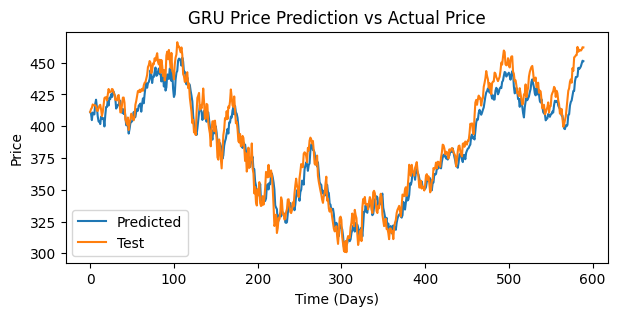

In [ ]:
# Extracting predictions
fig, ax = plt.subplots(figsize=(7, 3))
pd.Series(pred_inv).plot(ax=ax, label = 'Predicted')
pd.Series(y_test_inv).plot(ax=ax, label = "Test")
ax.legend()
plt.title('GRU Price Prediction vs Actual Price')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.show()

Reviewing the GRU model performance reveals that the model demonstrates strong predictive performance, although it does not exceed the baseline metrics set by the ARIMA model. The conservative metric of the RMSE indicates that, on average, the model’s predictions are erroneous by approximately 10 price units. A less conservative metric put the model’s forecast error closer to 8 price units. The standardized SMAPE reveals the model’s forecasts are off by 2%. The results from these performance metrics suggest that sentiment extracted from new headlines and a security's underlying price provides strong predictive performance of the future one-step closing price. Although the current set-up does not exceed the one-step predictive performance of the ARIMA model. This can be attributed to several factors.

One possibility is that the neural network only has 1,376 examples to train from, which may not be sufficient to learn complex patterns from the data. Neural networks are extremely flexible, and having such a small set of training examples leaves the model prone to overfitting. Overfitting occurs when a model learns not only the generalizable patterns in the data, but also the noise associated with it. To mitigate this issue, a dropout layer was included during model development to reduce overfitting and to learn generalizable patterns from the data. However, this may not be sufficient to prevent the model from incorporating random noise from the data in its predictions. A potential resolution to this issue is to decompose the Vanguard Information Technology ETF into its top 25 securities holdings. A model can be trained on these top 25 securities to learn more generalizable patterns in price. Later, the model parameters can be fine-tuned to the Vanguard technology ETF and the news sentiment dataset. This will provide the model with the large number of examples necessary to learn generalizable features from.

Another possibility could be that noise is being introduced from negative new predictions. Earlier is was seen that the precision and recall for the negative sentiment class were meaningfully lower than that of the neural and positive classes. As such, if the news dataset contains a meaningful amount of negative news headlines, the poor data quality being introduced may be hampering the model's overall predictive performance. This is something that will be explored more during the development of other modeling architectures, particularly the neural network that only makes use of univariate Vanguard Information Technology ETF prices.


# Model - 2 Transformer

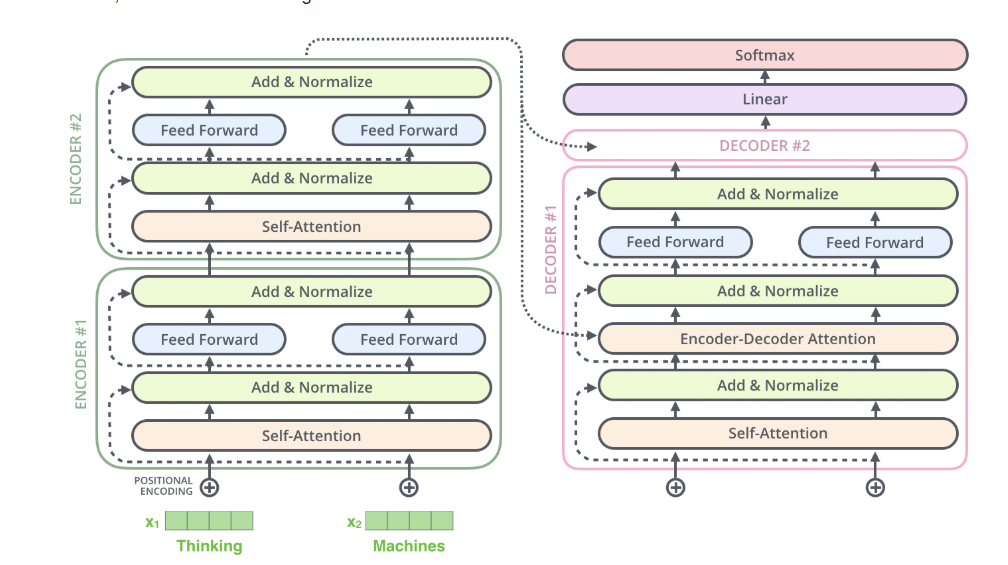

The transformer modeling architecture is an advanced neural network architecture that makes use of attention layers. In the context of time series analysis, an attention layer would be a vector embedding of an individual time element, with information about other time elements “baked” into its vector embedding. The idea is that, at a given time period, other time elements may be associated with the time element. Using attention, a time vector embedding would then be aware of other time elements or time steps to make more informed predictions. In practice, transformers make use of multiple attention heads, creating multiple attention representations of each time period, which are later multiplied by a learned weight matrix trained jointly with the model. The result of this multiplication produces an attention vector for each time period. Above is an illustration of this modeling architecture in the context of language translation.

The project will attempt to implement this modeling architecture for time series analysis. Although it is important to note that there are many hyperparameters to tune (e.g., number of attention heads, feed-forward layers), which make it challenging for modeling. A benefit of the transformer architecture is that it lends itself to parallelization, as each time element is processed independently in the feedforward layers, but not in the attention layers, as there are dependencies between time steps.


In [ ]:
from keras import layers
EMBED_DIM = 64
NUM_HEADS = 2
FF_DIM = 32
DROPOUT_RATE = 0.1
class TransformerBlock(layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.att = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=EMBED_DIM)
        self.ffn = models.Sequential([
            layers.Dense(FF_DIM, activation='relu'),
            layers.Dense(EMBED_DIM),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(DROPOUT_RATE)
        self.drop2 = layers.Dropout(DROPOUT_RATE)

    def call(self, inputs, training=False):

        # Self-attention over time
        attn_output = self.att(inputs, inputs)
        attn_output = self.drop1(attn_output, training=training)
        out1 = self.norm1(inputs + attn_output)

        # Position-wise feed-forward
        ffn_output = self.ffn(out1)
        ffn_output = self.drop2(ffn_output, training=training)
        return self.norm2(out1 + ffn_output)

In [ ]:
from keras import models
import tensorflow as tf

transformer_inputs = layers.Input(shape=(X_train.shape[1], X_train.shape[2]))

# Project numeric features into embedding space
proj = layers.Dense(EMBED_DIM, name='feature_projection')
transformer_x = proj(transformer_inputs)

# Learned positional embeddings
positions = tf.range(start=0, limit=X_train.shape[1], delta=1)
pos_embed = layers.Embedding(input_dim=X_train.shape[1], output_dim=EMBED_DIM, name='pos_embedding')(positions)
transformer_x = transformer_x + pos_embed

# Transformer encoder block
transformer_block = TransformerBlock(name='transformer_block')
transformer_x = transformer_block(transformer_x)

transformer_x = layers.Flatten()(transformer_x)
transformer_x = layers.Dense(128, activation='relu')(transformer_x)
transformer_x = layers.Dropout(0.05)(transformer_x)
transformer_outputs = layers.Dense(1, activation='linear')(transformer_x)
transformer_model = models.Model(transformer_inputs, transformer_outputs)

In [ ]:
# Model summary
transformer_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_projection (Dense)      │ (None, 30, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 64)         │        37,664 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,873 (1.08 MB)

 Trainable params: 283,873 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [ ]:
# Compiling model
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
# Creating callbacks
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=15,          # Stop after 5 epochs with no improvement
    min_delta=0.001,     # Minimum change to qualify as improvement
    verbose=2,           # Display messages when callback takes action
    restore_best_weights=True # Restore weights from the best epoch
)

# Creating callback to reduce the learning rate
from keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', # Metric to monitor
    factor=0.1,         # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=20,         # Number of epochs with no improvement
    min_lr=0.0001,      # Lower bound on the learning rate
    verbose=1
)

In [ ]:
# Fitting model
history = transformer_model.fit(x=X_train,y=y_train, epochs= 100, validation_split=0.15, batch_size=32, callbacks=[early_stopping, reduce_lr])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 34s 473ms/step - loss: 4.3190 - mae: 1.1951 - val_loss: 0.0112 - val_mae: 0.0884 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0711 - mae: 0.2059 - val_loss: 0.0052 - val_mae: 0.0582 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0267 - mae: 0.1269 - val_loss: 0.0092 - val_mae: 0.0819 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0138 - mae: 0.0933 - val_loss: 0.0063 - val_mae: 0.0664 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103 - mae: 0.0780 - val_loss: 0.0088 - val_mae: 0.0812 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0064 - mae: 0.0594 - val_loss: 0.0104 - val_mae: 0.0884 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - mae: 0.0533 - val_loss: 0.0086 - val_mae: 0.0805 - learning_rate: 0.0010
Epoch 8/10

In [ ]:
# Obtaining model statistics
r_loss, r_mae = transformer_model.evaluate(X_test, y_test, verbose=0)
print(f'Transformer — Test mae: {r_mae:.3f} | Loss: {r_loss:.3f}')
print('Transformer params:', transformer_model.count_params())

Transformer — Test mae: 0.086 | Loss: 0.012
Transformer params: 283873


In [ ]:
# Extracting predictions
pred = transformer_model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step


In [ ]:
# Converting scaled test data back to original units
y_test_inv = scaler.inverse_transform(
    np.c_[np.zeros((len(y_test), data.shape[1] - 1)), y_test] # Concatinating zero array with the true values
)[:, 1]

# Converting scaled predictions data back to original units
pred_inv = scaler.inverse_transform(
    np.c_[np.zeros((len(pred), data.shape[1] - 1)), pred] # Concatinating zero array with the predicted values
)[:, 1]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error

# Transformer predictions
Transformer_mse = mean_squared_error(y_test_inv, pred_inv)
Transformer_mae = mean_absolute_error(y_test_inv, pred_inv)
Transformer_rmae = root_mean_squared_error(y_test_inv, pred_inv)
Transformer_smape = calculate_smape(y_test_inv, pred_inv)

# Print Transformer performance
print(f"Transformer Performance:")
print(f"  MSE: {Transformer_mse:.6f}")
print(f"  RMSE: {Transformer_rmae:.6f}")
print(f"  MAE: {Transformer_mae:.6f}")
print(f"  SMAPE: {Transformer_smape:.6f}")

Transformer Performance:
  MSE: 1605.384532
  RMSE: 40.067250
  MAE: 32.046229
  SMAPE: 8.080000


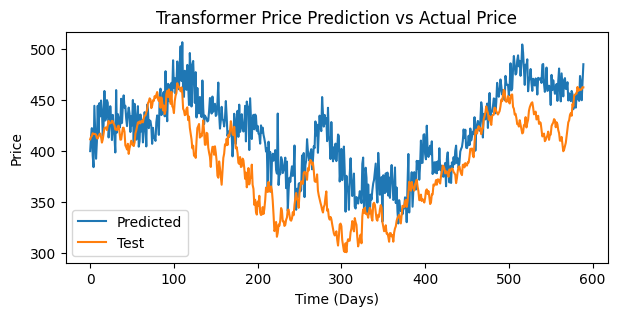

In [ ]:
# Extracting predictions
fig, ax = plt.subplots(figsize=(7, 3))
pd.Series(pred_inv).plot(ax=ax, label = 'Predicted')
pd.Series(y_test_inv).plot(ax=ax, label = "Test")
ax.legend()
plt.title('Transformer Price Prediction vs Actual Price')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.show()

The performance of the transformer model is sub-optimal. The visualization of the model performance demonstrates that the model overall follows price action, but does so in a way that is noisy and consistently overestimates. Viewing the quantitative statistics, the RMSE indicates that the model is erroneous by 40 price units. This is approximately 7 times more erroneous than the baseline ARIMA model. The SMAPE indicates that the average percentage error of the model is 8.08%, substantially higher than both the GRU neural network model and the baseline ARIMA model. The culprit for poor model performance is likely the lack of training data. The GRU model only has 67,329 parameters to train, whereas the transformer model has 283,873 parameters to train. The large number of parameters to train makes it highly prone to overfitting during model training, reducing the model's generalizability on unseen data. This is likely why the model’s predictions are erratic and noisy compared to the GRU model predictions seen earlier. To address this poor performance, more data would be necessary to employ such a large and complex model.

## Model 3 - LSTM

Long-short-term memory networks are a type of recurrent neural network that addresses the limitations of RNN architectures when working with long-term dependencies. These limitations include the vanishing gradient problem, where the weights of earlier layers experience difficulty in adjustment during backpropagation, and exploding gradients. Using memory cells composed of an input gate, forget gate, and an output gate, LSTM networks address the limitation of RNNs. These memory cells allow the network to selectively disregard irrelevant information as information passes through the network to retain long-term dependencies (GeeksforGeeks, 2026). Below is an implementation of this modeling architecture to forecast one-step price predictions of the Vanguard Information Technology ETF.

In [ ]:
from keras.layers import Input, LSTM, Dense, Dropout

# Creating LSTM model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2])) # (Sliding Window, Number of Features)
x = LSTM(124)(inputs)
x = Dense(256, activation='relu')(x)
x = Dropout(0.05)(x)
output = Dense(1)(x)

# Connecting symbolic input and outputs
LSTM_model = keras.models.Model(inputs, output)

# Model summary
LSTM_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 124)            │        62,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,249 (372.07 KB)

 Trainable params: 95,249 (372.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compiling model
LSTM_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
# Fitting model
history = LSTM_model.fit(x=X_train,y=y_train, epochs= 100, validation_split=0.15, batch_size=32, callbacks=[early_stopping, reduce_lr])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0079 - mae: 0.0545 - val_loss: 0.0015 - val_mae: 0.0325 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.6463e-04 - mae: 0.0139 - val_loss: 5.1441e-04 - val_mae: 0.0178 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.7851e-04 - mae: 0.0119 - val_loss: 5.3353e-04 - val_mae: 0.0189 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3974e-04 - mae: 0.0107 - val_loss: 4.7244e-04 - val_mae: 0.0169 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8510e-04 - mae: 0.0121 - val_loss: 0.0013 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5838e-04 - mae: 0.0115 - val_loss: 7.8052e-04 - val_mae: 0.0236 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.7324e-04 - mae: 0.0121 - val_loss: 8.0029e-04 - val_mae:

In [ ]:
# Model evaluation
r_loss, r_mae = LSTM_model.evaluate(X_test, y_test, verbose=0)
print(f'LSTM — Test mae: {r_mae:.3f} | Loss: {r_loss:.3f}')
print('LSTM params:', LSTM_model.count_params())

LSTM — Test mae: 0.022 | Loss: 0.001
LSTM params: 95249


In [ ]:
# Extracting predictions
pred = LSTM_model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
# Converting scaled test data back to original units
y_test_inv = scaler.inverse_transform(
    np.c_[np.zeros((len(y_test), data.shape[1] - 1)), y_test] # Concatinating zero array with the true values
)[:, 1]

# Converting scaled predictions back to original units
pred_inv = scaler.inverse_transform(
    np.c_[np.zeros((len(pred), data.shape[1] - 1)), pred] # Concatinating zero array with the predicted values
)[:, 1]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error
# LSTM predictions
LSTM_mse = mean_squared_error(y_test_inv, pred_inv)
LSTM_mae = mean_absolute_error(y_test_inv, pred_inv)
LSTM_rmae = root_mean_squared_error(y_test_inv, pred_inv)
LSTM_smape = calculate_smape(y_test_inv, pred_inv)

# Print LSTM performance
print(f"LSTM Performance:")
print(f"  MSE: {LSTM_mse:.6f}")
print(f"  RMSE: {LSTM_rmae:.6f}")
print(f"  MAE: {LSTM_mae:.6f}")
print(f"  SMAPE: {LSTM_smape:.6f}")

LSTM Performance:
  MSE: 108.138854
  RMSE: 10.398983
  MAE: 8.322439
  SMAPE: 2.170000


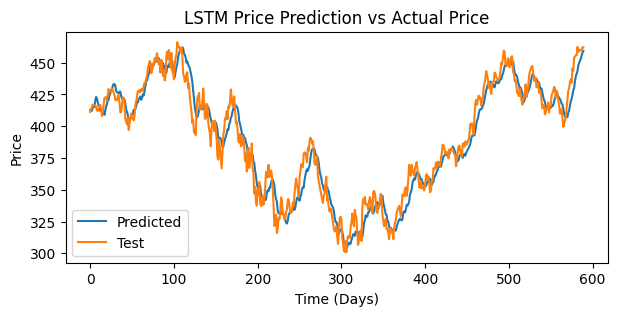

In [ ]:
# Extracting predictions
fig, ax = plt.subplots(figsize=(7, 3))
pd.Series(pred_inv).plot(ax=ax, label = 'Predicted')
pd.Series(y_test_inv).plot(ax=ax, label = "Test")
ax.legend()
plt.title('LSTM Price Prediction vs Actual Price')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.show()

The LSTM network exhibits strong predictive performance. Reviewing the illustration above,  the model's predictions (blue line) trace well the overall direction of price action. The model generates smooth trend following predictions, demonstrating great predictive performance. The quantitative metrics also convey strong predictive performance. The RMSE conveys that the models' forecasts are, on average, erroneous by 10.39 price units. The MAE places the model's average error closer to 8.32 price units. Lastly, the model’s SMAPE is 2.17, which is meaningfully better than the transformer model, but less than the GRU network and the baseline model. Next, we will evaluate a network trained only on the Vanguard Information Technology ETF prices for comparison of the various multivariate network models.

## Model 4 - LSTM (Price Only)

In [ ]:
# Dropping date colummn
data = df.drop(columns='Date')

In [ ]:
# Scaling data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [ ]:
# Adjusting sliding function
def sliding(data, window):
  X = []
  y = []

  for i in range(len(data) - window):
    X.append(data[i:i+window])
    y.append(data[i+window,0]) # Adjusting to be the first and only column

  return np.array(X),np.array(y)

# Scaling data
X,y=sliding(data_scaled, 30)

In [ ]:
# Creating a train, test split
split = int(0.70 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from keras.layers import Input, LSTM, Dense, Dropout

# Creating LSTM model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2])) # (Sliding Window, Number of Features)
x = LSTM(128)(inputs)
x = Dense(128, activation='relu')(x)
x = Dropout(0.05)(x)
output = Dense(1)(x)

# Connecting symbolic input and outputs
LSTM_model = keras.models.Model(inputs, output)

# Model summary
LSTM_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,201 (325.00 KB)

 Trainable params: 83,201 (325.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Creating callbacks
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop after 5 epochs with no improvement
    min_delta=0.001,     # Minimum change to qualify as improvement
    verbose=2,           # Display messages when callback takes action
    restore_best_weights=True # Restore weights from the best epoch
)

# Creating callback to reduce the learning rate
from keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', # Metric to monitor
    factor=0.2,         # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=5,         # Number of epochs with no improvement
    min_lr=0.0001,      # Lower bound on the learning rate
    verbose=1
)

In [ ]:
# Compiling model
LSTM_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
# Fitting model
history = LSTM_model.fit(x=X_train,y=y_train, epochs= 100, validation_split=0.15, batch_size=32, callbacks=[early_stopping, reduce_lr])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0071 - mae: 0.0521 - val_loss: 5.6726e-04 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.3035e-04 - mae: 0.0149 - val_loss: 3.8437e-04 - val_mae: 0.0151 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.3066e-04 - mae: 0.0124 - val_loss: 3.8863e-04 - val_mae: 0.0159 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.2373e-04 - mae: 0.0122 - val_loss: 0.0010 - val_mae: 0.0285 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.2240e-04 - mae: 0.0120 - val_loss: 6.6563e-04 - val_mae: 0.0227 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.0512e-04 - mae: 0.0116 - val_loss: 7.7549e-04 - val_mae: 0.0218 - learning_rate: 0.0010
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
# Model evaluation
r_loss, r_mae = LSTM_model.evaluate(X_test, y_test, verbose=0)
print(f'LSTM — Test mae: {r_mae:.3f} | Loss: {r_loss:.3f}')
print('LSTM params:', LSTM_model.count_params())

LSTM — Test mae: 0.028 | Loss: 0.001
LSTM params: 83201


In [ ]:
# Extracting predictions
pred = LSTM_model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
# Converting scaled test data back to original units
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))[:, 0]

# Converting scaled predictions back to original units
pred_inv = scaler.inverse_transform(pred)[:, 0]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error
# LSTM predictions
LSTM_mse = mean_squared_error(y_test_inv, pred_inv)
LSTM_mae = mean_absolute_error(y_test_inv, pred_inv)
LSTM_rmae = root_mean_squared_error(y_test_inv, pred_inv)
LSTM_smape = calculate_smape(y_test_inv, pred_inv)

# Print LSTM performance
print(f"LSTM Performance:")
print(f"  MSE: {LSTM_mse:.6f}")
print(f"  RMSE: {LSTM_rmae:.6f}")
print(f"  MAE: {LSTM_mae:.6f}")
print(f"  SMAPE: {LSTM_smape:.6f}")

LSTM Performance:
  MSE: 176.778459
  RMSE: 13.295806
  MAE: 10.447485
  SMAPE: 2.700000


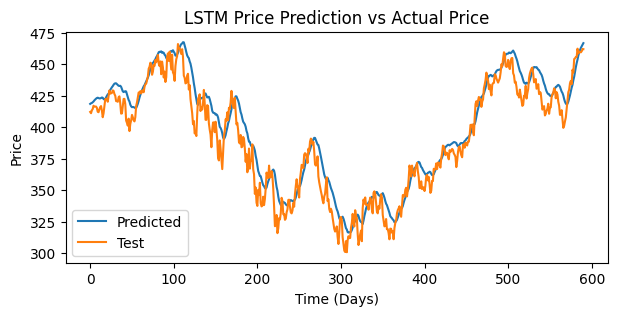

In [ ]:
# Extracting predictions
fig, ax = plt.subplots(figsize=(7, 3))
pd.Series(pred_inv).plot(ax=ax, label = 'Predicted')
pd.Series(y_test_inv).plot(ax=ax, label = "Test")
ax.legend()
plt.title('LSTM Price Prediction vs Actual Price')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.show()

This model serves as a baseline comparison of what to expect when training a univariate network on just price. The univariate LSTM network demonstrates adequate predictive performance compared to the multivariate network models, excluding the transformer model. Examining the performance statistics, the RMSE reports an average forecast error of 13.30 price units, whereas the MAE reports the average forecast error closer to 10.45. Both these metrics are slightly elevated compared to the multivariate LSTM network and the GRU network model, with the latter model being the most performant. The GRU model has an average RMSE of 10.04 and a SMAPE of 2.08 compared to the univariate LSTM networks RMSE of 13.30 and SMAPE of 2.70. This suggest that the addition of the news sentiment dataset does enhance a network’s ability to predict one-step forecasts. This alleviates concerns that the negative sentiment predictions was introducing noise that impairs the models ability to learn useful patterns from the data.

# Project Summary, key remarks, and conclusions

## Project Summary
This project explored whether incorporating news sentiment alongside a securities price improves a model’s predictive performance. First, baseline performance statistics were established using one-step predictions from ARIMA modeling. The initial baseline modeling revealed strong predictive performance with an average forecast error of 1.28%. Next, a BERT model was created using augmented textual data to support the class imbalances, helping bolster the classification performance across all classes. Utilizing the BERT model, sentiment predictions were made of new articles gathered from the top 25 stocks by weight of the Vanguard Information Technology ETF. After aggregating the predictions by date, a multivariate dataset was created containing daily ETF prices and daily aggregate sentiment. Four different network models were created in which key insights were discovered regarding news sentiment's impact on model performance.

## Key insights
Incorporating news sentiment does improve model performance. This insight was made by comparing the univariate LSTM network with the multivariate networks that incorporated news sentiment. Excluding the transformer model, all other network models experienced improvements in model performance compared to the network that solely incorporated univariate price.

This finding makes intuitive sense and was suggested early on during the exploration analysis. During the exploratory analysis, it was found that news sentiment served as a leading indicator of future price action. That is, when news sentiment was meaningfully positive or negative, prices reacted in a coordinated fashion (i.e., rising or falling).  Also, the correlation analysis indicated a moderate correlation between price and news sentiment, serving as another confluence. These findings make intuitive sense. While the markets have incorporated algorithmic trading that takes advantage of near-instant information, the markets are still moved by fundamentals. For instance, news regarding the Fed reducing the federal funds rate stimulates positive market sentiment, in which investors and firms alike react positively. Lower interest rates stimulate business investments, make it more affordable to take out a loan increasing consumer expenditures. Both of which are components of the basic macroeconomics GDP formulation. It is then not surprising that the price of a technological ETF, for instance, would rise in reaction to this price. Utilizing news sentiment provides a model with additional context of the real world, which is otherwise missed when relying exclusively on price. It is not surprising, then to see that a model that captures news sentiment adequately would bolster the predictive performance of the underlying model.  

ARIMA baseline performance statistics were never outperformed by any neural network, although this is likely due to the lack of training data. This finding is consistent with the overall observation seen when models with increased training parameters failed to perform better than simpler models. For instance, the transformer model had over 250,000 parameters to train, making it the most complex model architecture in the project. The performance statistics revealed very poor predictive performance, with an average forecast error of 8.08%. As we moved towards more efficient models (i.e., LTSM and GRU) it was generally found that less complex modeling architectures (e.g., GRU) generally performed better than others. Not having sufficient training examples to train large models prevents overly complex models from learning generalizable patterns during training that are useful for inference. They tend to fit not only on generalizable patterns in the data, but also to noise in the data as well. This concept was seen in virtually all network training instances where epochs generally had smaller training losses in subsequent passes, while validation loss stagnated or increased.

## Conclusion
At the beginning of the project, two main objectives were set:
- Does incorporating aggregated daily sentiment alongside univariate price improve predictive performance?

- Does incorporating news sentiment alongside price in network modeling improve predictive performance over traditional ARIMA modeling?

The result of the network modeling does demonstrate that using aggregated daily sentiment alongside univariate price does improve predictive performance. This is supported by both the LSTM and GRU networks, whose performance outperformed that of the univariate LSTM network. This finding is in alignment with current literature that sentiment influences a security's price. (Dahal , et al., 2023)

The results of the project do not support that incorporating news sentiment alongside price in network modeling outperforms traditional ARIMA modeling. This is likely due to insufficient training data and should not be taken as conclusive evidence that ARIMA modeling is superior. In fact, other studies have shown that utilizing sentiment analysis to predict a stock's price does outperform traditional statistical modeling. Future exploration for this project would be to train a model on multiple related securities, such as those securities that compose the Vanguard Information Technology ETF. One would then utilize this pretrained model and fine-tune it on the multivariate dataset trained in this project. This will give the models employed in this project sufficient data from which to train these models with large trainable parameters.

## References
Dahal , K. R., Pokhrel, N. R., Gaire, S., Mahatara , S., Joshi, R. P., Gupta , A., . . . Joshi , J. (2023). A comparative study on effect of news sentiment on stock price prediction with deep learning architecture. NLM.

Zeng, Q. (2025). Financial sentiment analysis using FinBERT with application in predicting stock movement.

